In [70]:
import pandas as pd
import numpy as np

from cdasws import CdasWs, TimeInterval

cdas = CdasWs()
from cdasws.datarepresentation import DataRepresentation as dr

In [71]:
from pathlib import Path


FILL_VALUES = [
    -1.0e31,
    -9.999999848243207e30,
    -99999.0,
    -999.9000244140625,
]


EARTH_RADIUS_KM = 6378.0
AU_KM = 149597870.7
LAST_VAR_UNITS = {}


def _normalize_unit(unit):
    if unit is None:
        return None
    u = str(unit).strip().lower()
    compact = u.replace(" ", "").replace("_", "")

    if "deg" in compact:
        return "deg"
    if compact == "au" or "astronomical" in compact:
        return "au"
    if "km" in compact:
        return "km"
    if (
        "earthradii" in compact
        or "earthradius" in compact
        or compact == "re"
        or "re" in compact
    ):
        return "re"
    return None


def infer_distance_unit(series, sat_name=""):
    s = pd.to_numeric(series, errors="coerce").dropna()
    if s.empty:
        return "re"

    abs_median = float(np.nanmedian(np.abs(s)))
    sat = sat_name.upper()

    if sat in {"STEREO", "PSP"} and abs_median < 5:
        return "au"
    if abs_median > 1000:
        return "km"
    return "re"


def _unit_to_re_factor(unit):
    if unit == "re":
        return 1.0
    if unit == "km":
        return 1.0 / EARTH_RADIUS_KM
    if unit == "au":
        return AU_KM / EARTH_RADIUS_KM
    raise ValueError(f"Unsupported distance unit: {unit}")


def coerce_distance_cols_to_re(df, cols, sat_name, unit_hint=None, default_unit=None):
    out = df.copy()
    hint = _normalize_unit(unit_hint) or _normalize_unit(default_unit)

    for col in cols:
        if col not in out.columns:
            continue

        chosen = hint or infer_distance_unit(out[col], sat_name=sat_name)
        if chosen == "deg":
            print(f"[{sat_name}] {col}: angle units detected ({unit_hint!r}), skipped.")
            continue

        factor = _unit_to_re_factor(chosen)
        numeric = pd.to_numeric(out[col], errors="coerce")

        if numeric.notna().any():
            med_before = float(np.nanmedian(np.abs(numeric)))
        else:
            med_before = np.nan

        out[col] = numeric * factor

        if out[col].notna().any():
            med_after = float(np.nanmedian(np.abs(out[col])))
        else:
            med_after = np.nan

        print(
            f"[{sat_name}] {col}: unit={chosen} -> R_e (x{factor:.9g}); "
            f"|median| {med_before:.6g} -> {med_after:.6g}"
        )

    return out


def clamp_bad_values(df, velocity_limit=1e5, magnetic_limit=1e5):
    cleaned = df.replace(FILL_VALUES, np.nan).copy()

    # Explicit B cleanup for Wind magnitude fill leaks
    if "B" in cleaned.columns:
        b = pd.to_numeric(cleaned["B"], errors="coerce")
        b = b.replace([1.7320508e31, -1.7320508e31], np.nan)
        cleaned["B"] = b.mask(b.abs() > magnetic_limit)

    for col in cleaned.select_dtypes(include=[np.number]).columns:
        name = col.lower()

        is_velocity = (
            name == "v"
            or name.startswith("v_")
            or "velocity" in name
            or "vx" in name
            or "vy" in name
            or "vz" in name
        )

        is_magnetic = (
            name == "b"
            or name.startswith("b_")
            or name in {"bt", "bx", "by", "bz"}
            or "magnetic" in name
        )

        if is_velocity:
            cleaned[col] = cleaned[col].mask(cleaned[col].abs() > velocity_limit)

        if is_magnetic:
            cleaned[col] = cleaned[col].mask(cleaned[col].abs() > magnetic_limit)

    return cleaned


def save_parquet(merged, sat, tShock, base_dir="Data"):
    shock_label = str(tShock.tz_localize(None)).replace(":", "-")
    out_dir = Path(base_dir) / shock_label
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / (sat + ".parquet")
    merged.to_parquet(out_path)
    return out_path

# Generic Helper Functions

This notebook uses helper functions for working with CDAS data:

1. **`list_datasets(observatory_group, instrument_type)`** - Lists all available datasets
2. **`download_and_unpack(datasets, dataset_index, time_interval, verbose=True)`** - Downloads and unpacks data to DataFrame
3. **`save_parquet(merged, sat, tShock, base_dir)`** - Saves merged data to parquet
4. **`unpack(data)`** - Unpacks CDAS VarCopy dictionary into DataFrame

**Example:**
```python
datasets = list_datasets("Wind", "Magnetic Fields (space)")
df = download_and_unpack(datasets, 6, time_interval)
```

In [72]:
def remove_spikes(series, threshold=100):
    """
    Простое удаление выбросов и изолированных точек.

    series: pd.Series или 1D np.array
    threshold: минимальная разница для удаления выброса
    """
    s = series.copy().astype(float)
    n = len(s)

    for i in range(n):
        curr = s[i]
        if np.isnan(curr):
            continue

        # соседние значения
        prev = s[i - 1] if i > 0 else np.nan
        next_ = s[i + 1] if i < n - 1 else np.nan

        # 1) изолированная точка
        if (np.isnan(prev) or prev == np.nan) and (np.isnan(next_) or next_ == np.nan):
            s[i] = np.nan
            continue

        # 2) резкий выброс
        neighbors = [x for x in [prev, next_] if not np.isnan(x)]
        if neighbors:
            if all(abs(curr - x) > threshold for x in neighbors):
                s[i] = np.nan

    return s

In [73]:
def list_datasets(observatory_group, instrument_type):
    """
    List available datasets for a given observatory and instrument type.

    Args:
        observatory_group: Observatory name (e.g., "Wind", "STEREO", "ACE", "THEMIS")
        instrument_type: Type of instrument (e.g., "Magnetic Fields (space)",
                        "Plasma and Solar Wind", "Particles (space)")

    Returns:
        List of datasets
    """
    datasets = cdas.get_datasets(
        observatoryGroup=observatory_group, instrumentType=instrument_type
    )
    print(f"\n=== {observatory_group} - {instrument_type} ===")
    for index, dataset in enumerate(datasets):
        dataset_id = dataset["Id"]
        dataset_label = dataset["Label"]
        print(f"{index}. {dataset_id}, {dataset_label}")
    return datasets


def download_and_unpack(datasets, dataset_index, time_interval, verbose=True):
    """
    Download and unpack a dataset from CDAS.

    Args:
        datasets: List of datasets from list_datasets()
        dataset_index: Index of the dataset to download
        time_interval: TimeInterval object for the data range
        verbose: Print variable information (default: True)

    Returns:
        DataFrame with unpacked data
    """
    global LAST_VAR_UNITS

    dataset = datasets[dataset_index]
    dataset_doi = dataset.get("Doi") or dataset.get("Id")

    # Get variables
    variables = cdas.get_variables(dataset_doi)
    var_names = []

    LAST_VAR_UNITS = {}

    if verbose:
        print(f"\n=== Variables for {dataset['Id']} ===")
        print(f"Time Interval: {dataset.get('TimeInterval', 'N/A')}")

    for index, variable in enumerate(variables):
        name = variable["Name"]
        var_names.append(name)
        unit = (
            variable.get("Units")
            or variable.get("Unit")
            or variable.get("UNITS")
            or variable.get("units")
        )
        LAST_VAR_UNITS[name] = unit
        if verbose:
            description = variable.get("LongDescription", "")
            print(f"{index}. {name}, {description} [units: {unit}]")

    # Download data
    _, data = cdas.get_data(
        dataset_doi, var_names, time_interval, dataRepresentation=dr.SPACEPY
    )

    # Unpack to DataFrame
    df = unpack(data)
    return df

In [74]:
def unpack(data_b):
    """
    Преобразует словарь VarCopy из Wind/CDAS в DataFrame.

    Правила:
    - выбирается максимальная длина временного ряда;
    - короткие переменные дополняются NaN;
    - многомерные массивы (векторы) кладутся списком в каждую строку;
    - скаляры и 1D массивы растягиваются до max_len.

    Печатает список финальных колонок.
    """

    # 1. Находим максимальную длину
    lengths = []
    for key in data_b.keys():
        arr = data_b[key][...]
        try:
            lengths.append(len(arr))
        except TypeError:
            lengths.append(1)  # 0-D массивы считаем длиной 1

    max_len = max(lengths)
    print(f"Максимальная длина временного ряда: {max_len}")

    # 2. Преобразуем данные для DataFrame
    df_dict = {}

    for key in data_b.keys():
        arr = np.asarray(data_b[key][...])

        if arr.ndim == 0:
            # 0-D скаляр → повторяем
            df_dict[key] = [arr.item()] * max_len
        elif arr.ndim == 1:
            # 1D массив → дополняем NaN
            padded = np.full(max_len, np.nan, dtype=object)
            padded[: len(arr)] = arr
            df_dict[key] = padded
        else:
            # многомерный массив → список в каждой строке, оставшиеся строки None
            padded = [None] * max_len
            for i in range(len(arr)):
                padded[i] = arr[i].tolist()
            df_dict[key] = padded

    # 3. Создаём DataFrame
    df = pd.DataFrame(df_dict)

    # 4. Печатаем финальные колонки
    print("Финальные колонки:", df.columns.tolist())

    return df

# Dates

In [75]:
import pandas as pd

tShock = pd.to_datetime("2022-11-24T19:10:00Z")

t2 = tShock + pd.Timedelta(hours=6)
t1 = tShock - pd.Timedelta(hours=6)

In [76]:
time_interval = TimeInterval(t1, t2)
t_start = pd.to_datetime(t1)
t_end = pd.to_datetime(t2)

# Wind

## B3GSE

In [77]:
# List and download Wind OMNI data for DST
datasets = list_datasets("Wind", "Magnetic Fields (space)")

# выбрать в datasets[N]["Doi"] номер N из списка выше, который нужно скачать---- 0 НАДО для DSt
N = 0
print("info---------", N, "---", datasets[N]["TimeInterval"])  # - инфо о данных :р
df = download_and_unpack(datasets, N, time_interval)


=== Wind - Magnetic Fields (space) ===
0. OMNI2_H0_MRG1HR, OMNI Combined, Definitive, Hourly IMF and Plasma Data, and Energetic Proton Fluxes, Time-Shifted to the Nose of the Earth's Bow Shock, plus Solar and Magnetic Indices - J.H. King, N. Papitashvili (ADNET, NASA GSFC)
1. OMNI_COHO1HR_MERGED_MAG_PLASMA, OMNI Combined merged hourly magnetic field, plasma and ephermis data - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
2. OMNI_HRO2_1MIN, OMNI Combined, Definitive 1-minute IMF and Definitive Plasma Data Time-Shifted to the Nose of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
3. OMNI_HRO2_5MIN, OMNI Combined, Definitive 5-minute IMF and Definitive Plasma, and Energetic Proton Fluxes, Time-Shifted to the Nose  of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
4. OMNI_HRO_1MIN, OMNI Combined, Definitive, 1-minute IMF and Plasma Data Time-Shifted to the Nose of the Earth

In [78]:
DST_omni = df.filter(["Epoch", "DST"], axis=1)
DST_omni = DST_omni.set_index("Epoch")

<Axes: title={'center': 'DST from Wind OMNI data'}, xlabel='Epoch', ylabel='DST, nT'>

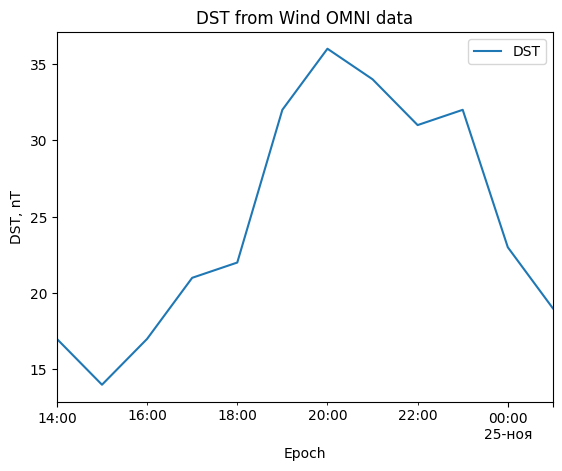

In [79]:
DST_omni.plot(title="DST from Wind OMNI data", ylabel="DST, nT")

In [80]:
# List available datasets for Wind magnetic field
datasets = list_datasets("Wind", "Magnetic Fields (space)")


=== Wind - Magnetic Fields (space) ===
0. OMNI2_H0_MRG1HR, OMNI Combined, Definitive, Hourly IMF and Plasma Data, and Energetic Proton Fluxes, Time-Shifted to the Nose of the Earth's Bow Shock, plus Solar and Magnetic Indices - J.H. King, N. Papitashvili (ADNET, NASA GSFC)
1. OMNI_COHO1HR_MERGED_MAG_PLASMA, OMNI Combined merged hourly magnetic field, plasma and ephermis data - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
2. OMNI_HRO2_1MIN, OMNI Combined, Definitive 1-minute IMF and Definitive Plasma Data Time-Shifted to the Nose of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
3. OMNI_HRO2_5MIN, OMNI Combined, Definitive 5-minute IMF and Definitive Plasma, and Energetic Proton Fluxes, Time-Shifted to the Nose  of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
4. OMNI_HRO_1MIN, OMNI Combined, Definitive, 1-minute IMF and Plasma Data Time-Shifted to the Nose of the Earth

In [81]:
print(datasets[6]["TimeInterval"])

{'Start': '1994-11-13T00:00:30.000Z', 'End': '2026-03-19T23:59:30.000Z'}


In [82]:
# Download Wind magnetic field data (3 sec resolution)
N = 6
df = download_and_unpack(datasets, N, time_interval)


=== Variables for WI_H0_MFI ===
Time Interval: {'Start': '1994-11-13T00:00:30.000Z', 'End': '2026-03-19T23:59:30.000Z'}
0. BF1, Magnetic field magnitude (1 min) [units: None]
1. BF1LOG, Magnetic field magnitude (1 min - log scaled) [units: None]
2. BRMSF1, RMS magnitude (1 min) [units: None]
3. BGSM, Magnetic field vector in GSM cartesian coordinates (1 min) [units: None]
4. BRMSGSM, RMS vector in GSM coordinates (1 min) [units: None]
5. BGSE, Magnetic field vector in GSE cartesian coordinates (1 min) [units: None]
6. BGSEa, Magnetic field vector in GSE angular coordinates (1 min) [units: None]
7. BRMSGSE, RMS vector in GSE coordinates (1 min) [units: None]
8. DIST, Distance from the center of the earth (Define Re = 6378km) (1 min) [units: None]
9. PGSM, Position vector in GSM coordinates (Define Re = 6378km) (1 min) [units: None]
10. PGSE, Position vector in GSE coordinates (Define Re = 6378km) (1 min) [units: None]
11. B3F1, Magnetic field magnitude (3 sec) [units: None]
12. B3F1LOG

In [83]:
# магнитное поле 3 sec
Wind_MFI = df.filter(["Epoch3", "B3GSE"], axis=1)
Wind_MFI = Wind_MFI.set_index("Epoch3")
Wind_MFI.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Wind_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE"]] = pd.DataFrame(
    Wind_MFI["B3GSE"].tolist(), index=Wind_MFI.index
)
Wind_MFI = Wind_MFI.drop(["B3GSE"], axis=1)
Wind_MFI["B"] = Wind_MFI.apply(
    lambda y: np.sqrt(y["B_X_GSE"] ** 2 + y["B_Y_GSE"] ** 2 + y["B_Z_GSE"] ** 2), axis=1
)
# фильтр плохих данных
Wind_MFI = clamp_bad_values(Wind_MFI)
Wind_MFI.info()
# усреднение 1 час начиная с 00
# df_MFI_1h_edit=df_MFI_1h.resample('1h').mean()

<class 'pandas.DataFrame'>
DatetimeIndex: 14400 entries, 2022-11-24 13:10:01.500000 to 2022-11-25 01:09:58.500000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   B_X_GSE  14292 non-null  float64
 1   B_Y_GSE  14292 non-null  float64
 2   B_Z_GSE  14292 non-null  float64
 3   B        14292 non-null  float64
dtypes: float64(4)
memory usage: 562.5 KB


<Axes: xlabel='Epoch3'>

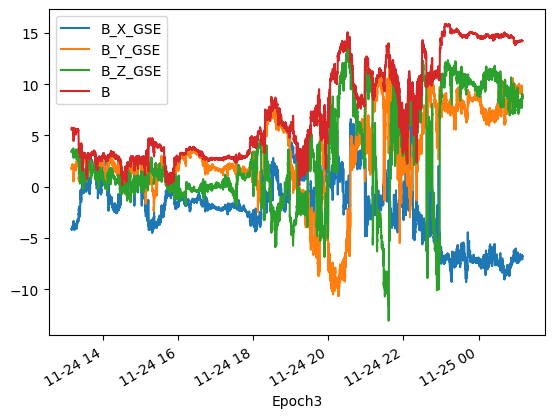

In [84]:
Wind_MFI.plot()

## PGSE

In [85]:
# магнитное поле 1 min
Wind_PGSE = df.filter(["Epoch", "PGSE"], axis=1)
Wind_PGSE = Wind_PGSE.set_index("Epoch")
Wind_PGSE.dropna(inplace=True)
Wind_PGSE

,PGSE
Epoch,
2022-11-24 13:10:30,"[208.7345733642578, 97.13078308105469, -1.8174..."
2022-11-24 13:11:30,"[208.7351837158203, 97.13167572021484, -1.8171..."
2022-11-24 13:12:30,"[208.7357940673828, 97.13256072998047, -1.8169..."
2022-11-24 13:13:30,"[208.7364044189453, 97.13345336914062, -1.8166..."
2022-11-24 13:14:30,"[208.7370147705078, 97.13434600830078, -1.8163..."
...,...
2022-11-25 01:05:30,"[209.17189025878906, 97.75183868408203, -1.615..."
2022-11-25 01:06:30,"[209.17250061035156, 97.752685546875, -1.61472..."
2022-11-25 01:07:30,"[209.17311096191406, 97.75352478027344, -1.614..."


In [86]:
# распаковка списка bx by bz в отдельные столбцы
Wind_PGSE[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    Wind_PGSE["PGSE"].tolist(), index=Wind_PGSE.index
)
Wind_PGSE = Wind_PGSE.drop(["PGSE"], axis=1)
# фильтр плохих данных
Wind_PGSE = clamp_bad_values(Wind_PGSE)
Wind_PGSE = coerce_distance_cols_to_re(
    Wind_PGSE,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="Wind",
    unit_hint=LAST_VAR_UNITS.get("PGSE"),
    default_unit="re",
)
Wind_PGSE.info()
# усреднение 1 час начиная с 00
# df_PGSE_1h_edit=df_PGSE_1h.resample('1h').mean()

[Wind] X_GSE: unit=re -> R_e (x1); |median| 208.955 -> 208.955
[Wind] Y_GSE: unit=re -> R_e (x1); |median| 97.4472 -> 97.4472
[Wind] Z_GSE: unit=re -> R_e (x1); |median| 1.7158 -> 1.7158
<class 'pandas.DataFrame'>
DatetimeIndex: 720 entries, 2022-11-24 13:10:30 to 2022-11-25 01:09:30
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X_GSE   720 non-null    float64
 1   Y_GSE   720 non-null    float64
 2   Z_GSE   720 non-null    float64
dtypes: float64(3)
memory usage: 22.5 KB


## SWE

In [87]:
# List available datasets for Wind plasma
datasets = list_datasets("Wind", "Plasma and Solar Wind")

# Download Wind SWE data
N = 11  # WI_K0_SWE
df = download_and_unpack(datasets, N, time_interval)


=== Wind - Plasma and Solar Wind ===
0. OMNI2_H0_MRG1HR, OMNI Combined, Definitive, Hourly IMF and Plasma Data, and Energetic Proton Fluxes, Time-Shifted to the Nose of the Earth's Bow Shock, plus Solar and Magnetic Indices - J.H. King, N. Papitashvili (ADNET, NASA GSFC)
1. OMNI_COHO1HR_MERGED_MAG_PLASMA, OMNI Combined merged hourly magnetic field, plasma and ephermis data - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
2. OMNI_HRO2_1MIN, OMNI Combined, Definitive 1-minute IMF and Definitive Plasma Data Time-Shifted to the Nose of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
3. OMNI_HRO2_5MIN, OMNI Combined, Definitive 5-minute IMF and Definitive Plasma, and Energetic Proton Fluxes, Time-Shifted to the Nose  of the Earth's Bow Shock, plus Magnetic Indices - J.H. King, N. Papatashvilli (AdnetSystems, NASA GSFC)
4. OMNI_HRO_1MIN, OMNI Combined, Definitive, 1-minute IMF and Plasma Data Time-Shifted to the Nose of the Earth's

In [88]:
datasets[11]["TimeInterval"]

{'Start': '1994-11-17T19:50:45.000Z', 'End': '2026-01-20T23:57:25.000Z'}

In [89]:
# СВ
Wind_SW = df.filter(
    [
        "Epoch",
        "Proton_V_moment",
        "Proton_VX_moment",
        "Proton_VY_moment",
        "Proton_VZ_moment",
        "Proton_Np_nonlin",
    ],
    axis=1,
)
Wind_SW = Wind_SW.rename(
    columns={
        "Proton_V_moment": "V",
        "Proton_VX_moment": "V_X_GSE",
        "Proton_VY_moment": "V_Y_GSE",
        "Proton_VZ_moment": "V_Z_GSE",
        "Proton_Np_nonlin": "N_p",
    }
)
Wind_SW

,Epoch,V,V_X_GSE,V_Y_GSE,V_Z_GSE,N_p
0,2022-11-24 13:13:21.276,315.455933,-315.154816,0.483418,-13.771748,10.262467
1,2022-11-24 13:16:38.885,323.975067,-323.876984,-0.473063,-7.957356,10.098452
2,2022-11-24 13:36:43.359,312.808563,-311.940399,-0.752819,-23.27696,14.602491
3,2022-11-24 13:38:23.732,312.026215,-311.175812,-1.566195,-22.967941,14.335897
4,2022-11-24 13:40:04.104,312.3479,-311.422882,-3.044187,-23.827309,14.017771
...,...,...,...,...,...,...
365,2022-11-25 00:59:46.727,393.639954,-393.549133,-4.205065,7.336091,10.029813
366,2022-11-25 01:01:27.099,392.560638,-392.485779,5.965355,4.815477,10.122592
367,2022-11-25 01:03:04.336,391.485657,-391.30719,-6.624731,9.789089,10.524403
368,2022-11-25 01:04:44.708,391.208435,-391.132111,-3.445508,6.916022,10.173372


In [90]:
Wind_SW = Wind_SW.set_index("Epoch")
Wind_SW.dropna(inplace=True)


# Wind_SW = Wind_SW.drop(["V_GSE"], axis=1)
# Wind_SW["v"] = Wind_SW.apply(
#     lambda y: np.sqrt(y["v_x"] ** 2 + y["v_y"] ** 2 + y["v_z"] ** 2), axis=1
# )
# фильтр плохих данных (удаляет всю строку)
Wind_SW = clamp_bad_values(Wind_SW)
Wind_SW.info()

# усреднение 1 час начиная с 00
# df_SW_1h_edit=df_SW_1h.resample('1h').mean()

# 1 день - 7 секунд

<class 'pandas.DataFrame'>
DatetimeIndex: 370 entries, 2022-11-24 13:13:21.276000 to 2022-11-25 01:06:25.081000
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   V        370 non-null    object
 1   V_X_GSE  370 non-null    object
 2   V_Y_GSE  370 non-null    object
 3   V_Z_GSE  370 non-null    object
 4   N_p      370 non-null    object
dtypes: object(5)
memory usage: 17.3+ KB


<Axes: xlabel='Epoch'>

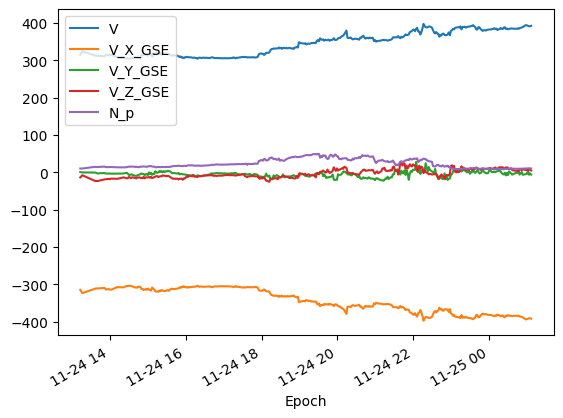

In [91]:
# Wind_SW_cleaned = Wind_SW.copy()
# Wind_SW_cleaned["N_p"] = remove_spikes(
#     Wind_SW["N_p"], threshold=15
# )
# Wind_SW_cleaned["Proton_V_nonlin"] = remove_spikes(
#     Wind_SW["Proton_V_nonlin"], threshold=100
# )

# Wind_SW_cleaned["Proton_V_nonlin"] = Wind_SW_cleaned["Proton_V_nonlin"].loc[
#     Wind_SW_cleaned["Proton_V_nonlin"] < 600
# ]

# Wind_SW_cleaned["V_X_GSE"] = remove_spikes(
#     Wind_SW["V_X_GSE"], threshold=100
# )
# Wind_SW_cleaned["V_Y_GSE"] = remove_spikes(
#     Wind_SW["V_Y_GSE"], threshold=100
# )
# #.loc[Wind_SW_cleaned["V_Y_GSE"] < -600]

# Wind_SW_cleaned["V_Z_GSE"] = remove_spikes(
#     Wind_SW["V_Z_GSE"], threshold=100
# )
Wind_SW.plot()
# Wind_SW_cleaned.plot()

## Plot and Export

In [92]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

Общий диапазон: 2022-11-24 13:13:21.276000 — 2022-11-25 01:06:25.081000


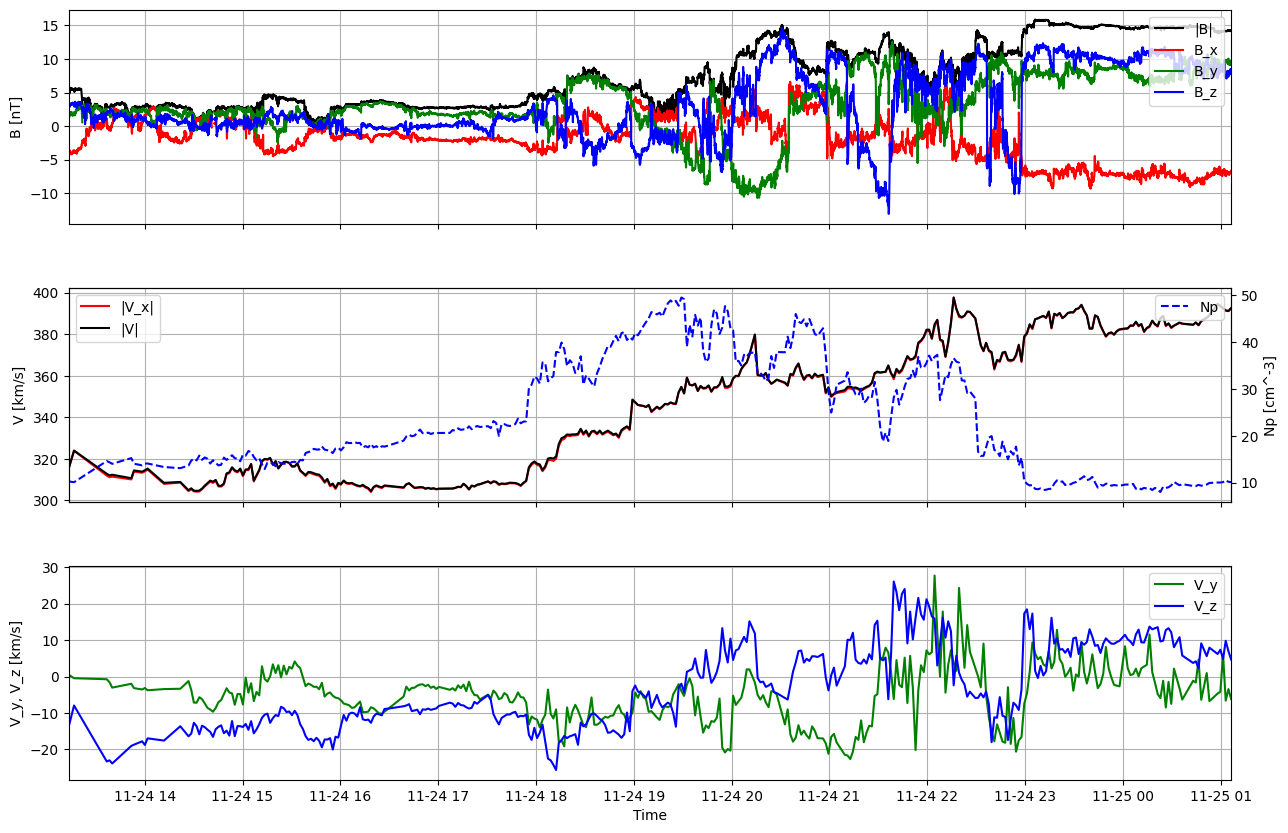

In [93]:
# 1. Определяем общий интервал
t_start = max(Wind_SW.index.min(), Wind_MFI.index.min())
t_end = min(Wind_SW.index.max(), Wind_MFI.index.max())
print(f"Общий диапазон: {t_start} — {t_end}")

# 2. Обрезаем данные по интервалу
SW = Wind_SW[(Wind_SW.index >= t_start) & (Wind_SW.index <= t_end)]
MFI = Wind_MFI[(Wind_MFI.index >= t_start) & (Wind_MFI.index <= t_end)]

t = (
    SW.index
)  # используем индекс SW для построения, можно интерполяцией привести MFI к этому индексу

# --- Теперь строим график как раньше ---
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
plt.subplots_adjust(hspace=0.3)

# Верхняя панель: поле
ax = axes[0]
ax.plot(MFI.index, MFI["B"], "k", label="|B|")
ax.plot(MFI.index, MFI["B_X_GSE"], "r", label="B_x")
ax.plot(MFI.index, MFI["B_Y_GSE"], "g", label="B_y")
ax.plot(MFI.index, MFI["B_Z_GSE"], "b", label="B_z")
ax.set_ylabel("B [nT]")
ax.legend(loc="upper right")
ax.grid(True)
ax.set_xlim(t_start, t_end)  # единый масштаб

# Средняя панель: V и Np
ax = axes[1]

ax.plot(SW.index, abs(SW["V_X_GSE"]), "r", label="|V_x|")
ax.plot(SW.index, SW["V"], "k", label="|V|")
ax.set_ylabel("V [km/s]")
ax.grid(True)
ax.legend(loc="upper left")

ax2 = ax.twinx()
ax2.plot(SW.index, SW["N_p"], "b", label="Np", linestyle="--")
ax2.set_ylabel("Np [cm^-3]")
ax2.legend(loc="upper right")

ax.set_xlim(t_start, t_end)

# Нижняя панель: Vy и Vz
ax = axes[2]
ax.plot(SW.index, SW["V_Y_GSE"], "g", label="V_y")
SW_cl = SW.loc[SW["V_Z_GSE"] > -600]
ax.plot(SW_cl.index, SW_cl["V_Z_GSE"], "b", label="V_z")
ax.set_ylabel("V_y, V_z [km/s]")
ax.set_xlabel("Time")
ax.legend(loc="upper right")
ax.grid(True)
ax.set_xlim(t_start, t_end)

# Форматирование времени
# axes[-1].xaxis.set_major_locator(mdates.DayLocator())
# axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
# axes[-1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
# plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")

for ax in axes:
    ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)

plt.show()

In [94]:
mfi = Wind_MFI.copy()
sw = Wind_SW.copy()
coord = Wind_PGSE.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
sw = clamp_bad_values(sw)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

merged = pd.merge_asof(
    mfi_u,
    sw_u,
    on="Epoch",
    direction="nearest",
    tolerance=tol,
    suffixes=("_mfi", "_sw"),
)
merged = pd.merge_asof(merged, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols + sw_cols, how="all")

In [95]:
merged

,B_X_GSE,B_Y_GSE,B_Z_GSE,B,V,V_X_GSE,V_Y_GSE,V_Z_GSE,N_p,X_GSE,Y_GSE,Z_GSE
Epoch,,,,,,,,,,,,
2022-11-24 13:10:01.500000+00:00,-4.105991,1.734110,3.382721,5.595454,NaN,NaN,NaN,NaN,NaN,208.734573,97.130783,-1.817466
2022-11-24 13:10:04.500000+00:00,-4.126194,1.791272,3.382514,5.628102,NaN,NaN,NaN,NaN,NaN,208.734573,97.130783,-1.817466
2022-11-24 13:10:07.500000+00:00,-4.109220,1.812756,3.413234,5.641094,NaN,NaN,NaN,NaN,NaN,208.734573,97.130783,-1.817466
2022-11-24 13:10:10.500000+00:00,-4.127900,1.787060,3.476408,5.684941,NaN,NaN,NaN,NaN,NaN,208.734573,97.130783,-1.817466
2022-11-24 13:10:13.500000+00:00,-4.176602,1.754232,3.442029,5.689367,NaN,NaN,NaN,NaN,NaN,208.734573,97.130783,-1.817466
...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25 01:09:46.500000+00:00,-6.739325,8.729708,8.976192,14.219646,NaN,NaN,NaN,NaN,NaN,209.174332,97.755219,-1.613875
2022-11-25 01:09:49.500000+00:00,-6.772990,8.599761,9.056766,14.207543,NaN,NaN,NaN,NaN,NaN,209.174332,97.755219,-1.613875
2022-11-25 01:09:52.500000+00:00,-6.894939,8.835998,8.766483,14.229064,NaN,NaN,NaN,NaN,NaN,209.174332,97.755219,-1.613875


In [96]:
save_parquet(merged, "Wind", tShock)

WindowsPath('Data/2022-11-24 19-10-00/Wind.parquet')

# STEREO

## Mag

In [97]:
# List available datasets for STEREO magnetic field
datasets = list_datasets("STEREO", "Magnetic Fields (space)")

# Download STEREO magnetic field data
N = 5
df = download_and_unpack(datasets, N, time_interval)


=== STEREO - Magnetic Fields (space) ===
0. STA_COHO1HR_MERGED_MAG_PLASMA, Merged hourly magnetic field, plasma, proton fluxes, and ephermis data - Natasha Papitashvili (NASA/GSFC)
1. STA_L1_IMPACT_BURST, STEREO Ahead IMPACT Burst Criteria. - Christina Lee (UCB/SSL)
2. STA_L1_IMPACT_HKP, STEREO Ahead IMPACT State of Health	 - Christina Lee (UCB/SSL)
3. STA_L1_MAGB_RTN, STEREO Ahead IMPACT/MAG Burst Mode (~0.03 sec) Magnetic Field Vectors (RTN) - Christina Lee (UCB/SSL)
4. STA_L1_MAGB_SC, STEREO Ahead IMPACT/MAG Burst Mode (~0.03 sec) Magnetic Field Vectors (SC) - Christina Lee (UCB/SSL)
5. STA_L1_MAG_RTN, STEREO Ahead IMPACT/MAG Magnetic Field Vectors (RTN) - Christina Lee (UCB/SSL)
6. STA_L1_MAG_SC, STEREO Ahead IMPACT/MAG Magnetic Field Vectors (SC) - Christina Lee (UCB/SSL)
7. STA_L2_MAGPLASMA_1M, STEREO Ahead IMPACT/MAG Magnetic Field and PLASTIC Solar Wind Plasma Data - Christina Lee (UCB/SSL)
8. STA_LB_IMPACT, STEREO Ahead IMPACT Beacon Data - Christina Lee (UCB/SSL)
9. STA_LB_M

In [98]:
Stereo_MFI = df.filter(["Epoch", "BFIELD"], axis=1)
Stereo_MFI = Stereo_MFI.set_index("Epoch")
Stereo_MFI.dropna(inplace=True)

# распаковка списка bx by bz в отдельные столбцы
Stereo_MFI[["B_X_HGE", "B_Y_HGE", "B_Z_HGE", "B"]] = pd.DataFrame(
    Stereo_MFI["BFIELD"].tolist(), index=Stereo_MFI.index
)
Stereo_MFI = Stereo_MFI.drop(["BFIELD"], axis=1)
# Stereo["B"] = Stereo.apply(lambda y: np.sqrt(y["B_X_HGE"] ** 2 + y["B_Y_HGE"] ** 2 + y["B_Z_HGE"] ** 2), axis=1)
# фильтр плохих данных
Stereo_MFI = clamp_bad_values(Stereo_MFI)
Stereo_MFI.info()
# усреднение 1 секунда начиная с 00
Stereo_MFI_1s = Stereo_MFI.resample("1s").mean()

<class 'pandas.DataFrame'>
DatetimeIndex: 345601 entries, 2022-11-24 13:10:00 to 2022-11-25 01:09:59.978000
Data columns (total 4 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   B_X_HGE  345599 non-null  float64
 1   B_Y_HGE  345599 non-null  float64
 2   B_Z_HGE  345599 non-null  float64
 3   B        345599 non-null  float64
dtypes: float64(4)
memory usage: 13.2 MB


<Axes: xlabel='Epoch'>

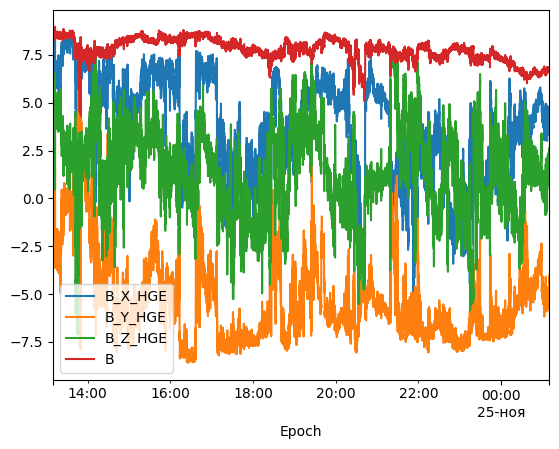

In [99]:
Stereo_MFI_1s.plot()

## PLASTIC

In [100]:
# List available datasets for STEREO plasma
datasets = list_datasets("STEREO", "Plasma and Solar Wind")


=== STEREO - Plasma and Solar Wind ===
0. STA_COHO1HR_MERGED_MAG_PLASMA, Merged hourly magnetic field, plasma, proton fluxes, and ephermis data - Natasha Papitashvili (NASA/GSFC)
1. STA_L1_IMPACT_BURST, STEREO Ahead IMPACT Burst Criteria. - Christina Lee (UCB/SSL)
2. STA_L1_IMPACT_HKP, STEREO Ahead IMPACT State of Health	 - Christina Lee (UCB/SSL)
3. STA_L1_STE, STEREO Ahead IMPACT/STE Spectra - Christina Lee (UCB/SSL)
4. STA_L1_SWEA_DISB, STEREO Ahead IMPACT/SWEA 3D Burst Mode Distributions. - Christina Lee (UCB/SSL)
5. STA_L1_SWEA_DIST, STEREO Ahead IMPACT/SWEA 3D Distributions. - Christina Lee (UCB/SSL)
6. STA_L1_SWEA_SPEC, STEREO Ahead IMPACT/SWEA Spectra - Christina Lee (UCB/SSL)
7. STA_L2_MAGPLASMA_1M, STEREO Ahead IMPACT/MAG Magnetic Field and PLASTIC Solar Wind Plasma Data - Christina Lee (UCB/SSL)
8. STA_L2_PLA_1DMAX_10MIN, STEREO Ahead PLASTIC Level 2  - Dr. Antoinette Galvin (University of New Hampshire)
9. STA_L2_PLA_1DMAX_1HR, STEREO Ahead PLASTIC Level 2  - Dr. Antoinett

In [101]:
# Download STEREO PLASTIC data
N = 10
df = download_and_unpack(datasets, N, time_interval)


=== Variables for STA_L2_PLA_1DMAX_1MIN ===
Time Interval: {'Start': '2007-02-14T00:00:37.000Z', 'End': '2025-06-30T23:59:05.000Z'}
0. error, Indicates possible error condition. [units: None]
1. caution, Indicates how sensitive the density value is to method for determining background correction. [units: None]
2. attitude_flag, Indicates when instrument flow angles are not in nominal s/c orientation. [units: None]
3. ew_source_flag, Source flag for EW data. [units: None]
4. ew_boxcar, E/W BoxCar Interval. [units: None]
5. proton_number_density, Proton Number Density. 1D Maxwellian Fit. [units: None]
6. proton_bulk_speed, Proton Bulk Speed. 1D Maxwellian Fit. [units: None]
7. proton_temperature, Proton Temperature. 1D Maxwellian Fit. [units: None]
8. proton_thermal_speed, Proton Thermal Speed. 1D Maxwellian Fit. [units: None]
9. proton_n_s_flow_angle_inst, Proton N/S Flow Angle. 1D Maxwellian Fit. Instrument Coordinates. [units: None]
10. proton_e_w_flow_angle_inst, Proton E/W Flow Ang

In [102]:
# магнитное поле 1 min
Stereo_SW = df.filter(
    ["epoch", "proton_number_density", "proton_bulk_speed", "proton_temperature"],
    axis=1,
)
Stereo_SW = Stereo_SW.set_index("epoch")
Stereo_SW = Stereo_SW.rename(
    columns={
        "proton_number_density": "N_p",
        "proton_bulk_speed": "V",
        "proton_temperature": "T_p",
    }
)
Stereo_SW_cleaned = Stereo_SW.copy()
Stereo_SW_cleaned["T_p"] = remove_spikes(Stereo_SW_cleaned["T_p"], threshold=10000)
Stereo_SW_cleaned["N_p"] = remove_spikes(Stereo_SW_cleaned["N_p"], threshold=10000)
Stereo_SW_cleaned["V"] = remove_spikes(Stereo_SW_cleaned["V"], threshold=10000)
Stereo_SW_cleaned["T_p"] = Stereo_SW_cleaned["T_p"].replace(
    -9.999999848243207e30, np.nan
)
Stereo_SW_cleaned["N_p"] = Stereo_SW_cleaned["N_p"].replace(
    -9.999999848243207e30, np.nan
)
Stereo_SW_cleaned["V"] = Stereo_SW_cleaned["V"].replace(-9.999999848243207e30, np.nan)
Stereo_SW_cleaned = clamp_bad_values(Stereo_SW_cleaned)
-9.999999848243207e30
# Stereo_SW.dropna(inplace=True)

KeyError: 0

<Axes: xlabel='epoch'>

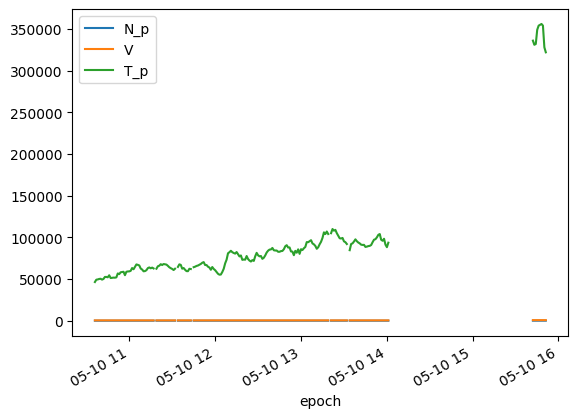

In [ ]:
Stereo_SW_cleaned.plot()

## Coord

In [ ]:
# List available datasets for STEREO coordinates (reuse plasma list)
datasets = list_datasets("STEREO", "Plasma and Solar Wind")


=== STEREO - Plasma and Solar Wind ===
0. STA_COHO1HR_MERGED_MAG_PLASMA, Merged hourly magnetic field, plasma, proton fluxes, and ephermis data - Natasha Papitashvili (NASA/GSFC)
1. STA_L1_IMPACT_BURST, STEREO Ahead IMPACT Burst Criteria. - Christina Lee (UCB/SSL)
2. STA_L1_IMPACT_HKP, STEREO Ahead IMPACT State of Health	 - Christina Lee (UCB/SSL)
3. STA_L1_STE, STEREO Ahead IMPACT/STE Spectra - Christina Lee (UCB/SSL)
4. STA_L1_SWEA_DISB, STEREO Ahead IMPACT/SWEA 3D Burst Mode Distributions. - Christina Lee (UCB/SSL)
5. STA_L1_SWEA_DIST, STEREO Ahead IMPACT/SWEA 3D Distributions. - Christina Lee (UCB/SSL)
6. STA_L1_SWEA_SPEC, STEREO Ahead IMPACT/SWEA Spectra - Christina Lee (UCB/SSL)
7. STA_L2_MAGPLASMA_1M, STEREO Ahead IMPACT/MAG Magnetic Field and PLASTIC Solar Wind Plasma Data - Christina Lee (UCB/SSL)
8. STA_L2_PLA_1DMAX_10MIN, STEREO Ahead PLASTIC Level 2  - Dr. Antoinette Galvin (University of New Hampshire)
9. STA_L2_PLA_1DMAX_1HR, STEREO Ahead PLASTIC Level 2  - Dr. Antoinett

In [ ]:
# Download STEREO coordinate data
N = 0
df = download_and_unpack(datasets, N, time_interval)


=== Variables for STA_COHO1HR_MERGED_MAG_PLASMA ===
Time Interval: {'Start': '2007-01-01T00:00:00.000Z', 'End': '2025-12-31T23:00:00.000Z'}
0. radialDistance, Radial Distance [units: None]
1. heliographicLatitude, HelioGraphic Inertial (HGI) latitude of the spacecraft position at the start of data interval [units: None]
2. heliographicLongitude, HelioGraphic Inertial (HGI) longitude of the spacecraft position at the start of data interval  [units: None]
3. BR, IMF BR in RTN (Radial-Tangential-Normal) coordinate system [units: None]
4. BT, IMF BT in RTN coordinate system [units: None]
5. BN, IMF BN in RTN coordinate system [units: None]
6. B, B Field Magnitude (average of fine scale magnitudes) [units: None]
7. plasmaSpeed, SW plasma speed [units: None]
8. lat, SW lat angle in RTN coordinate system  [units: None]
9. lon, SW lon angle in RTN coordinate system  [units: None]
10. plasmaDensity, SW plasma density [units: None]
11. plasmaTemp, SW plasma Temperature [units: None]
12. protonF

In [ ]:
Stereo_HGE = df.filter(
    ["Epoch", "radialDistance", "heliographicLatitude", "heliographicLongitude"],
)
Stereo_HGE = Stereo_HGE.set_index("Epoch")
Stereo_HGE = coerce_distance_cols_to_re(
    Stereo_HGE,
    ["radialDistance"],
    sat_name="STEREO",
    unit_hint=LAST_VAR_UNITS.get("radialDistance"),
    default_unit="au",
)

[STEREO] radialDistance: unit=au -> R_e (x23455.2949); |median| 0.96 -> 22517.1


## Plot and Export

In [ ]:
# #Построение графиков для Stereo если они в одном датафрейме
# t = Stereo.index  # используем индекс Stereo для построения, можно интерполяцией привести Stereo к этому индексу

# # --- Теперь строим график как раньше ---
# fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)
# plt.subplots_adjust(hspace=0.3)

# # Верхняя панель: поле
# ax = axes[0]
# ax.plot(Stereo.index, Stereo['B'], 'k', label='|B|')
# ax.plot(Stereo.index, Stereo['B_X_HGE'], 'r', label='B_x')
# ax.plot(Stereo.index, Stereo['B_Y_HGE'], 'g', label='B_y')
# ax.plot(Stereo.index, Stereo['B_Z_HGE'], 'b', label='B_z')
# ax.set_ylabel('B [nT]')
# ax.legend(loc='upper right')
# ax.grid(True)
# ax.set_xlim(t_start, t_end)  # единый масштаб

# # Средняя панель: V и Np
# ax = axes[1]

# ax.plot(Stereo.index, Stereo['V'], 'k', label='|V|')
# ax.set_ylabel('V [km/s]')
# ax.grid(True)
# ax.legend(loc='upper left')

# ax2 = ax.twinx()
# ax2.plot(Stereo.index, Stereo['N_p'], 'b', label='Np', linestyle='--')
# ax2.set_ylabel('Np [cm^-3]')
# ax2.legend(loc='upper right')

# ax.set_xlim(t_start, t_end)

# # Нижняя панель: температура
# ax = axes[2]
# ax.plot(Stereo.index, Stereo['T_p'], 'g', label='T')
# ax.set_yscale('log')
# ax.set_ylabel('T [K]')
# ax.set_xlabel('Time')
# ax.legend(loc='upper right')
# ax.grid(True)
# ax.set_xlim(t_start, t_end)

# # Форматирование времени
# axes[-1].xaxis.set_major_locator(mdates.DayLocator())
# axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))
# axes[-1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0,6,12,18]))
# plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha='right')

# for ax in axes:
#     ax.grid(which='minor', linestyle='--', color='lightgrey', alpha=0.5)

# plt.show()

In [ ]:
mfi = Stereo_MFI_1s.copy()
sw = Stereo_SW_cleaned.copy()
coord = Stereo_HGE.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
sw = clamp_bad_values(sw)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

merged = pd.merge_asof(
    mfi_u,
    sw_u,
    on="Epoch",
    direction="nearest",
    tolerance=tol,
    suffixes=("_mfi", "_sw"),
)
merged = pd.merge_asof(merged, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols + sw_cols, how="all")

/var/folders/3z/b4fclst96kbd90mb019v618m0000gn/T/ipykernel_62594/1147378891.py:101: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cleaned = df.replace(FILL_VALUES, np.nan).copy()


In [ ]:
merged

,B_X_HGE,B_Y_HGE,B_Z_HGE,B,N_p,V,T_p,radialDistance,heliographicLatitude,heliographicLongitude
Epoch,,,,,,,,,,
2024-05-10 10:36:00+00:00,-2.813581,-2.147558,3.361415,4.881671,4.59,396.0,46400.0,NaN,NaN,NaN
2024-05-10 10:36:01+00:00,-2.691317,-2.216891,3.348619,4.834423,4.59,396.0,46400.0,NaN,NaN,NaN
2024-05-10 10:36:02+00:00,-2.729924,-2.250566,3.331582,4.859814,4.59,396.0,46400.0,NaN,NaN,NaN
2024-05-10 10:36:03+00:00,-2.762593,-2.196564,3.347712,4.864699,4.59,396.0,46400.0,NaN,NaN,NaN
2024-05-10 10:36:04+00:00,-2.797199,-2.172919,3.361811,4.883483,4.59,396.0,46400.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-05-10 22:35:55+00:00,24.395819,-0.100254,-47.566078,53.460517,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-10 22:35:56+00:00,24.307689,-0.283900,-47.147330,53.048701,NaN,NaN,NaN,NaN,NaN,NaN
2024-05-10 22:35:57+00:00,24.147114,0.478173,-47.198136,53.021300,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
parquet_path = save_parquet(merged, "STEREO", tShock)

# ACE

## Magnetic Field

In [103]:
# List available datasets for ACE magnetic field
datasets = list_datasets("ACE", "Magnetic Fields (space)")

# Download ACE magnetic field data
N = 4
df = download_and_unpack(datasets, N, time_interval)


=== ACE - Magnetic Fields (space) ===
0. AC_AT_DEF, ACE Hourly RTN, GSE and J2000 GCI Attitude direction cosines - E. C. Stone (California Institute of Technology)
1. AC_H0_MFI, H0 - ACE Magnetic Field 16-Second Level 2 Data - N. Ness (Bartol Research Institute)
2. AC_H1_MFI, H1 - ACE Magnetic Field 4-Minute Level 2 Data - N. Ness (Bartol Research Institute)
3. AC_H2_MFI, H2 - ACE Magnetic Field 1-Hour Level 2 Data - N. Ness (Bartol Research Institute)
4. AC_H3_MFI, H3 - ACE Magnetic Field 1-Second Level 2 Data - N. Ness (Bartol Research Institute)
5. AC_K0_GIFWALK, Links to ACE KP pre-generated survey and other plots - Polar-Wind-Geotail Ground System (NASA GSFC)
6. AC_K0_MFI, ACE Magnetic Field 5-Minute Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
7. AC_K1_MFI, ACE Magnetic Field 16-Second Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
8. AC_K2_MFI, K2 - ACE Magnetic Field 1-Hour Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
9. AC_OR_D

<class 'pandas.DataFrame'>
DatetimeIndex: 43200 entries, 2022-11-24 13:10:00.867000 to 2022-11-25 01:09:59.782000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   B_X_GSE  43200 non-null  float64
 1   B_Y_GSE  43200 non-null  float64
 2   B_Z_GSE  43200 non-null  float64
 3   B        43200 non-null  float64
dtypes: float64(4)
memory usage: 1.6 MB


<Axes: xlabel='Epoch'>

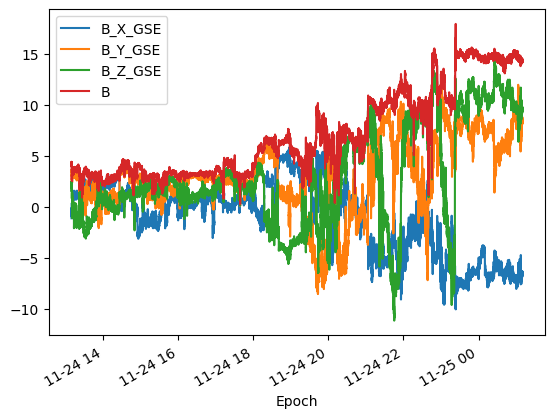

In [104]:
# магнитное поле 1 min
Ace_MFI = df.filter(["Epoch", "Magnitude", "BGSEc"], axis=1)
Ace_MFI = Ace_MFI.set_index("Epoch")
Ace_MFI.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Ace_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE"]] = pd.DataFrame(
    Ace_MFI["BGSEc"].tolist(), index=Ace_MFI.index
)
Ace_MFI = Ace_MFI.drop(["BGSEc"], axis=1)
Ace_MFI["B"] = Ace_MFI.Magnitude
Ace_MFI = Ace_MFI.drop(["Magnitude"], axis=1)
# фильтр плохих данных
Ace_MFI = clamp_bad_values(Ace_MFI)
Ace_MFI.info()
# усреднение 1 час начиная с 00
# df_MFI_1h_edit=df_MFI_1h.resample('1h').mean()
Ace_MFI.plot()

## Solar Wind

In [105]:
# List available datasets for ACE plasma
datasets = list_datasets("ACE", "Plasma and Solar Wind")


=== ACE - Plasma and Solar Wind ===
0. AC_AT_DEF, ACE Hourly RTN, GSE and J2000 GCI Attitude direction cosines - E. C. Stone (California Institute of Technology)
1. AC_H0_SWE, ACE/SWEPAM Solar Wind Experiment 64-Second Level 2 Data - D. J. McComas (SWRI)
2. AC_H2_SWE, ACE/SWEPAM Solar Wind Experiment 1-Hour Level 2 Data - D. J. McComas (SWRI)
3. AC_H2_SWI, ACE/SWICS 1.1 Solar Wind 1-Hour Level 2 Data - G. Gloeckler (University of Maryland)
4. AC_H3_SW2, ACE/SWICS 2.0 Solar Wind 2-Hour Level 2 Data - G. Gloeckler (University of Maryland)
5. AC_H3_SWI, ACE/SWICS 1.1 Solar Wind 2-Hour Level 2 Data - G. Gloeckler (University of Maryland)
6. AC_H4_SWI, ACE/SWICS 1.1 Solar Wind 1-Day Level 2 Data - G. Gloeckler (University of Maryland)
7. AC_H5_SWI, ACE/SWICS 1.1 Solar Wind 2-Hour Level 2 Q-state distributions - G. Gloeckler (University of Maryland)
8. AC_H6_SWI, ACE/SWICS Solar Wind Protons 12-min Level 2 Data - G. Gloeckler (University of Maryland)
9. AC_K0_GIFWALK, Links to ACE KP pre-ge

In [107]:
# Download ACE plasma data
N = 1
df = download_and_unpack(datasets, N, time_interval)


=== Variables for AC_H0_SWE ===
Time Interval: {'Start': '1998-02-04T00:00:31.000Z', 'End': '2024-07-09T23:59:13.000Z'}
0. Np, Solar Wind Proton Number Density, scalar [units: None]
1. Vp, Solar Wind Bulk Speed [units: None]
2. Tpr, radial component of the proton temperature [units: None]
3. alpha_ratio, alpha to proton density ratio [units: None]
4. V_GSE, Solar Wind Velocity in GSE coord., 3 components [units: None]
5. V_RTN, Solar Wind Velocity in RTN coord., 3 components [units: None]
6. V_GSM, Solar Wind Velocity in GSM coord., 3 comp. [units: None]
7. SC_pos_GSE, ACE s/c position, 3 comp. in GSE coord. [units: None]
8. SC_pos_GSM, ACE s/c position, 3 comp. in GSM coord. [units: None]
Максимальная длина временного ряда: 675
Финальные колонки: ['Epoch', 'Np', 'Vp', 'Tpr', 'alpha_ratio', 'V_GSE', 'V_RTN', 'V_GSM', 'SC_pos_GSE', 'SC_pos_GSM', 'metavar0', 'metavar1', 'metavar2', 'metavar3', 'metavar4']


In [108]:
datasets[N]["TimeInterval"]

{'Start': '1998-02-04T00:00:31.000Z', 'End': '2024-07-09T23:59:13.000Z'}

In [109]:
Ace_SW = df.copy()
Ace_SW = Ace_SW.set_index("Epoch")
Ace_SW = Ace_SW.rename(
    columns={
        "Vp": "V",
        "Np": "N_p",
    }
)

if "V_GSE" in Ace_SW.columns:
    Ace_SW[["V_X_GSE", "V_Y_GSE", "V_Z_GSE"]] = pd.DataFrame(
        Ace_SW["V_GSE"].tolist(), index=Ace_SW.index
    )
    Ace_SW = Ace_SW.drop(["V_GSE"], axis=1)

In [110]:
for col in ["V", "N_p", "V_X_GSE", "V_Y_GSE", "V_Z_GSE"]:
    if col in Ace_SW.columns:
        Ace_SW[col] = Ace_SW[col].replace(-999.9000244140625, np.nan)
Ace_SW = clamp_bad_values(Ace_SW)

In [111]:
Ace_SW

,N_p,V,Tpr,alpha_ratio,V_RTN,V_GSM,SC_pos_GSE,SC_pos_GSM,metavar0,metavar1,metavar2,metavar3,metavar4,V_X_GSE,V_Y_GSE,V_Z_GSE
Epoch,,,,,,,,,,,,,,,,
2022-11-24 13:10:19,NaN,320.73999,42851.199219,NaN,"[319.8550109863281, -18.16900062561035, 15.390...","[-319.84698486328125, 21.784000396728516, 6.12...","[1397260.0, -69163.0, 148668.0]","[1397260.0, -17448.0, 163038.0]",VX (GSE),VR (RTN),VX (GSM),ACE X-GSE,ACE X(GSM),-319.846985,19.815001,13.381000
2022-11-24 13:11:23,NaN,316.869995,49959.199219,NaN,"[316.7969970703125, -4.520999908447266, 5.2810...","[-316.7929992675781, 5.085999965667725, 2.9800...","[1397259.0, -69156.0, 148669.0]","[1397259.0, -17524.0, 163027.0]",VY (GSE),VT (RTN),VY (GSM),ACE Y-GSE,ACE Y(GSM),-316.792999,5.036000,5.011000
2022-11-24 13:12:27,NaN,312.98999,39485.898438,NaN,"[312.90301513671875, 3.0329999923706055, 6.491...","[-312.8949890136719, -1.1970000267028809, 7.35...","[1397258.0, -69149.0, 148669.0]","[1397258.0, -17600.0, 163016.0]",VZ (GSE),VN (RTN),VZ (GSM),ACE Z-GSE,ACE Z(GSM),-312.894989,-2.313000,7.130000
2022-11-24 13:13:31,NaN,311.559998,43660.800781,NaN,"[311.5450134277344, 2.7320001125335693, 1.7640...","[-311.5409851074219, -2.990999937057495, 2.963...","[1397257.0, -69141.0, 148670.0]","[1397257.0, -17676.0, 163005.0]",NaN,NaN,NaN,NaN,NaN,-311.540985,-2.591000,2.401000
2022-11-24 13:14:35,NaN,313.839996,32884.300781,NaN,"[313.8219909667969, 3.052000045776367, 1.98300...","[-313.8179931640625, -3.191999912261963, 3.301...","[1397256.0, -69134.0, 148670.0]","[1397256.0, -17753.0, 162994.0]",NaN,NaN,NaN,NaN,NaN,-313.817993,-2.882000,2.660000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25 01:04:59,NaN,393.329987,91493.101562,NaN,"[390.072998046875, -1.5800000429153442, 50.462...","[-390.02398681640625, 11.204999923706055, 50.2...","[1396690.0, -64175.0, 148930.0]","[1396690.0, -56696.0, 151934.0]",NaN,NaN,NaN,NaN,NaN,-390.023987,7.638000,50.286999
2022-11-25 01:06:03,NaN,398.640015,96296.296875,NaN,"[395.4049987792969, -2.993000030517578, 50.576...","[-395.3559875488281, 12.647000312805176, 50.12...","[1396689.0, -64168.0, 148930.0]","[1396689.0, -56620.0, 151960.0]",NaN,NaN,NaN,NaN,NaN,-395.355988,9.053000,50.233002
2022-11-25 01:07:07,NaN,396.929993,115246.703125,NaN,"[393.6409912109375, -22.20400047302246, 45.887...","[-393.6050109863281, 30.79400062561035, 42.182...","[1396688.0, -64160.0, 148931.0]","[1396688.0, -56542.0, 151986.0]",NaN,NaN,NaN,NaN,NaN,-393.605011,27.547001,43.224998


In [112]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. общий интервал
# t_start = max(Stereo.index.min(), Wind_SW_cleaned.index.min())
# t_end   = min(Stereo.index.max(), Wind_SW_cleaned.index.max())
# t_start=pd.to_datetime("2024-06-26" )
# t_end=pd.to_datetime("2024-06-30" )

## Coord

In [113]:
# List available datasets for ACE coordinates
datasets = list_datasets("ACE", "Magnetic Fields (space)")


=== ACE - Magnetic Fields (space) ===
0. AC_AT_DEF, ACE Hourly RTN, GSE and J2000 GCI Attitude direction cosines - E. C. Stone (California Institute of Technology)
1. AC_H0_MFI, H0 - ACE Magnetic Field 16-Second Level 2 Data - N. Ness (Bartol Research Institute)
2. AC_H1_MFI, H1 - ACE Magnetic Field 4-Minute Level 2 Data - N. Ness (Bartol Research Institute)
3. AC_H2_MFI, H2 - ACE Magnetic Field 1-Hour Level 2 Data - N. Ness (Bartol Research Institute)
4. AC_H3_MFI, H3 - ACE Magnetic Field 1-Second Level 2 Data - N. Ness (Bartol Research Institute)
5. AC_K0_GIFWALK, Links to ACE KP pre-generated survey and other plots - Polar-Wind-Geotail Ground System (NASA GSFC)
6. AC_K0_MFI, ACE Magnetic Field 5-Minute Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
7. AC_K1_MFI, ACE Magnetic Field 16-Second Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
8. AC_K2_MFI, K2 - ACE Magnetic Field 1-Hour Key Parameters [PRELIM] - N. Ness (Bartol Research Institute)
9. AC_OR_D

In [114]:
# Download ACE coordinate data
N = 1
df = download_and_unpack(datasets, N, time_interval)


=== Variables for AC_H0_MFI ===
Time Interval: {'Start': '1997-09-02T00:00:12.000Z', 'End': '2026-02-23T23:59:57.000Z'}
0. Magnitude, B-field magnitude [units: None]
1. BGSEc, Magnetic Field Vector in GSE Cartesian coordinates (16 sec) [units: None]
2. BGSM, Magnetic field vector in GSM coordinates (16 sec) [units: None]
3. dBrms, RMS of Magnetic Field (16 sec period) [units: None]
4. SC_pos_GSE, ACE s/c position, 3 comp. in GSE coord. [units: None]
5. SC_pos_GSM, ACE s/c position, 3 comp. in GSM coord. [units: None]
Максимальная длина временного ряда: 2700
Финальные колонки: ['Epoch', 'Magnitude', 'BGSEc', 'BGSM', 'dBrms', 'SC_pos_GSE', 'SC_pos_GSM', 'cartesian', 'metavar0', 'metavar1', 'metavar2', 'metavar3']


<class 'pandas.DataFrame'>
DatetimeIndex: 2700 entries, 2022-11-24 13:10:12 to 2022-11-25 01:09:56
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X_GSE   2700 non-null   float64
 1   Y_GSE   2700 non-null   float64
 2   Z_GSE   2700 non-null   float64
dtypes: float64(3)
memory usage: 84.4 KB
[ACE] X_GSE: unit=km -> R_e (x0.000156788962); |median| 1.39698e+06 -> 219.031
[ACE] Y_GSE: unit=km -> R_e (x0.000156788962); |median| 66659 -> 10.4514
[ACE] Z_GSE: unit=km -> R_e (x0.000156788962); |median| 148813 -> 23.3322


<Axes: xlabel='Epoch'>

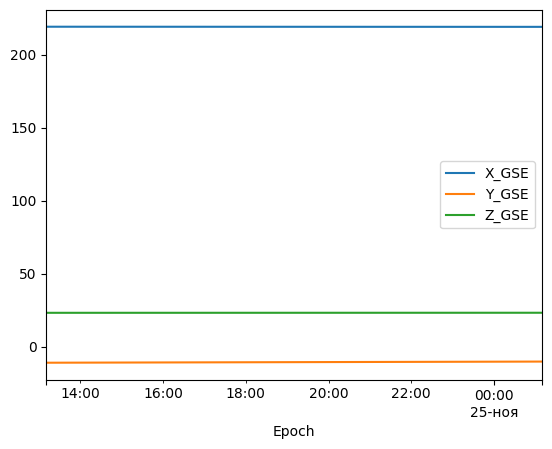

In [115]:
# магнитное поле 1 min
Ace_GSE = df.filter(["Epoch", "SC_pos_GSE"], axis=1)
Ace_GSE = Ace_GSE.set_index("Epoch")
Ace_GSE.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Ace_GSE[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    Ace_GSE["SC_pos_GSE"].tolist(), index=Ace_GSE.index
)
Ace_GSE = Ace_GSE.drop(["SC_pos_GSE"], axis=1)
Ace_GSE.info()
# усреднение 1 час начиная с 00
# df_GSE_1h_edit=df_GSE_1h.resample('1h').mean()
Ace_GSE = clamp_bad_values(Ace_GSE)
Ace_GSE = coerce_distance_cols_to_re(
    Ace_GSE,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="ACE",
    unit_hint=LAST_VAR_UNITS.get("SC_pos_GSE"),
)
Ace_GSE.plot()

## Plot and Export

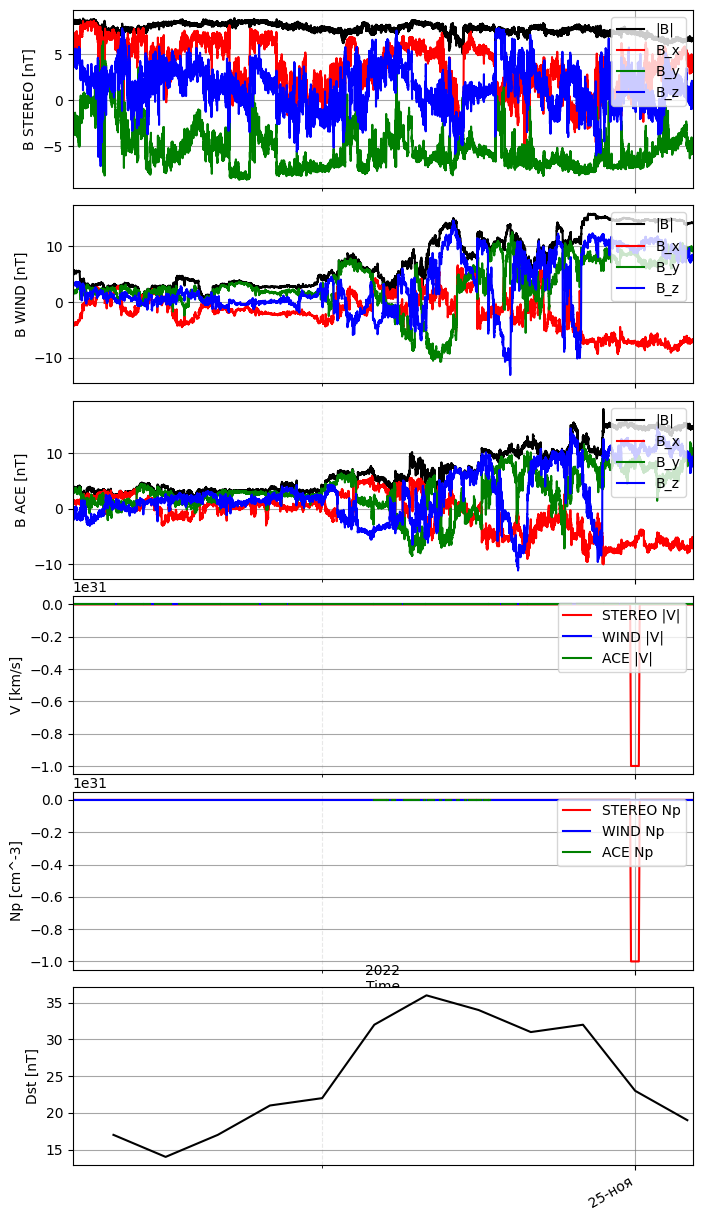

In [116]:
# Crop data to time range
ST_MFI = Stereo_MFI[(Stereo_MFI.index >= t_start) & (Stereo_MFI.index <= t_end)]
ST_SW = Stereo_SW_cleaned[
    (Stereo_SW_cleaned.index >= t_start) & (Stereo_SW_cleaned.index <= t_end)
]
Wind_MFI_cr = Wind_MFI[(Wind_MFI.index >= t_start) & (Wind_MFI.index <= t_end)]
Wind_SW_cr = Wind_SW[(Wind_SW.index >= t_start) & (Wind_SW.index <= t_end)]
DST_omni_cr = DST_omni[(DST_omni.index >= t_start) & (DST_omni.index <= t_end)]
Ace_SW_cr = Ace_SW[(Ace_SW.index >= t_start) & (Ace_SW.index <= t_end)]
Ace_MFI_cr = Ace_MFI[(Ace_MFI.index >= t_start) & (Ace_MFI.index <= t_end)]

# --- Plot ---
fig, axes = plt.subplots(6, 1, figsize=(8, 15), sharex=True)
plt.subplots_adjust(hspace=0.1)

# ---------------- 1. STEREO Magnetic Field ----------------
ax = axes[0]
ax.plot(ST_MFI.index, ST_MFI["B"], "k", label="|B|")
ax.plot(ST_MFI.index, ST_MFI["B_X_HGE"], "r", label="B_x")
ax.plot(ST_MFI.index, ST_MFI["B_Y_HGE"], "g", label="B_y")
ax.plot(ST_MFI.index, ST_MFI["B_Z_HGE"], "b", label="B_z")
ax.set_ylabel("B STEREO [nT]")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 2. WIND Magnetic Field ----------------
ax = axes[1]
ax.plot(Wind_MFI_cr.index, Wind_MFI_cr["B"], "k", label="|B|")
ax.plot(Wind_MFI_cr.index, Wind_MFI_cr["B_X_GSE"], "r", label="B_x")
ax.plot(Wind_MFI_cr.index, Wind_MFI_cr["B_Y_GSE"], "g", label="B_y")
ax.plot(Wind_MFI_cr.index, Wind_MFI_cr["B_Z_GSE"], "b", label="B_z")
ax.set_ylabel("B WIND [nT]")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 3. ACE Magnetic Field ----------------
ax = axes[2]
ax.plot(Ace_MFI_cr.index, Ace_MFI_cr["B"], "k", label="|B|")
ax.plot(Ace_MFI_cr.index, Ace_MFI_cr["B_X_GSE"], "r", label="B_x")
ax.plot(Ace_MFI_cr.index, Ace_MFI_cr["B_Y_GSE"], "g", label="B_y")
ax.plot(Ace_MFI_cr.index, Ace_MFI_cr["B_Z_GSE"], "b", label="B_z")
ax.set_ylabel("B ACE [nT]")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 4. Velocity ----------------
ax = axes[3]
ax.plot(ST_SW.index, ST_SW["V"], "r", label="STEREO |V|")
ax.plot(Wind_SW_cr.index, Wind_SW_cr["V"], "b", label="WIND |V|")
ax.plot(Ace_SW_cr.index, Ace_SW_cr["V"], "g", label="ACE |V|")
ax.set_ylabel("V [km/s]")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 5. Density ----------------
ax = axes[4]
ax.plot(ST_SW.index, ST_SW["N_p"], "r", label="STEREO Np")
ax.plot(Wind_SW_cr.index, Wind_SW_cr["N_p"], "b", label="WIND Np")
ax.plot(Ace_SW_cr.index, Ace_SW_cr["N_p"], "g", label="ACE Np")
ax.set_ylabel("Np [cm^-3]")
ax.set_xlabel("Time")
ax.legend(loc="upper right")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- 6. Dst ----------------
ax = axes[5]
ax.plot(DST_omni_cr.index, DST_omni_cr["DST"], "k", label="Dst")
ax.set_ylabel("Dst [nT]")
ax.grid(which="major", linestyle="-", color="grey", alpha=0.7)
ax.grid(which="minor", linestyle="--", color="lightgrey", alpha=0.5)
ax.set_xlim(t_start, t_end)

# ---------------- Formatting ----------------
axes[-1].xaxis.set_major_locator(mdates.DayLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))
axes[-1].xaxis.set_minor_locator(mdates.HourLocator(byhour=[0, 6, 12, 18]))
plt.setp(axes[-1].xaxis.get_majorticklabels(), rotation=30, ha="right")
axes[-1].text(
    0.5,
    1.05,
    f"{t_start:%Y}",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10,
)

plt.show()

In [117]:
mfi = Ace_MFI.copy()
sw = Ace_SW.copy()
coord = Ace_GSE.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
sw = clamp_bad_values(sw)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

merged = pd.merge_asof(
    mfi_u,
    sw_u,
    on="Epoch",
    direction="nearest",
    tolerance=tol,
    suffixes=("_mfi", "_sw"),
)
merged = pd.merge_asof(merged, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols + sw_cols, how="all")

In [118]:
sw_u

,Epoch,N_p,V,Tpr,alpha_ratio,V_RTN,V_GSM,SC_pos_GSE,SC_pos_GSM,metavar0,metavar1,metavar2,metavar3,metavar4,V_X_GSE,V_Y_GSE,V_Z_GSE
0,2022-11-24 13:10:19+00:00,NaN,320.73999,42851.199219,NaN,"[319.8550109863281, -18.16900062561035, 15.390...","[-319.84698486328125, 21.784000396728516, 6.12...","[1397260.0, -69163.0, 148668.0]","[1397260.0, -17448.0, 163038.0]",VX (GSE),VR (RTN),VX (GSM),ACE X-GSE,ACE X(GSM),-319.846985,19.815001,13.381000
1,2022-11-24 13:11:23+00:00,NaN,316.869995,49959.199219,NaN,"[316.7969970703125, -4.520999908447266, 5.2810...","[-316.7929992675781, 5.085999965667725, 2.9800...","[1397259.0, -69156.0, 148669.0]","[1397259.0, -17524.0, 163027.0]",VY (GSE),VT (RTN),VY (GSM),ACE Y-GSE,ACE Y(GSM),-316.792999,5.036000,5.011000
2,2022-11-24 13:12:27+00:00,NaN,312.98999,39485.898438,NaN,"[312.90301513671875, 3.0329999923706055, 6.491...","[-312.8949890136719, -1.1970000267028809, 7.35...","[1397258.0, -69149.0, 148669.0]","[1397258.0, -17600.0, 163016.0]",VZ (GSE),VN (RTN),VZ (GSM),ACE Z-GSE,ACE Z(GSM),-312.894989,-2.313000,7.130000
3,2022-11-24 13:13:31+00:00,NaN,311.559998,43660.800781,NaN,"[311.5450134277344, 2.7320001125335693, 1.7640...","[-311.5409851074219, -2.990999937057495, 2.963...","[1397257.0, -69141.0, 148670.0]","[1397257.0, -17676.0, 163005.0]",NaN,NaN,NaN,NaN,NaN,-311.540985,-2.591000,2.401000
4,2022-11-24 13:14:35+00:00,NaN,313.839996,32884.300781,NaN,"[313.8219909667969, 3.052000045776367, 1.98300...","[-313.8179931640625, -3.191999912261963, 3.301...","[1397256.0, -69134.0, 148670.0]","[1397256.0, -17753.0, 162994.0]",NaN,NaN,NaN,NaN,NaN,-313.817993,-2.882000,2.660000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,2022-11-25 01:04:59+00:00,NaN,393.329987,91493.101562,NaN,"[390.072998046875, -1.5800000429153442, 50.462...","[-390.02398681640625, 11.204999923706055, 50.2...","[1396690.0, -64175.0, 148930.0]","[1396690.0, -56696.0, 151934.0]",NaN,NaN,NaN,NaN,NaN,-390.023987,7.638000,50.286999
671,2022-11-25 01:06:03+00:00,NaN,398.640015,96296.296875,NaN,"[395.4049987792969, -2.993000030517578, 50.576...","[-395.3559875488281, 12.647000312805176, 50.12...","[1396689.0, -64168.0, 148930.0]","[1396689.0, -56620.0, 151960.0]",NaN,NaN,NaN,NaN,NaN,-395.355988,9.053000,50.233002
672,2022-11-25 01:07:07+00:00,NaN,396.929993,115246.703125,NaN,"[393.6409912109375, -22.20400047302246, 45.887...","[-393.6050109863281, 30.79400062561035, 42.182...","[1396688.0, -64160.0, 148931.0]","[1396688.0, -56542.0, 151986.0]",NaN,NaN,NaN,NaN,NaN,-393.605011,27.547001,43.224998
673,2022-11-25 01:08:11+00:00,NaN,396.220001,105233.796875,NaN,"[392.9939880371094, -10.270999908447266, 49.39...","[-392.95001220703125, 19.674999237060547, 47.6...","[1396687.0, -64153.0, 148931.0]","[1396687.0, -56465.0, 152012.0]",NaN,NaN,NaN,NaN,NaN,-392.950012,16.132999,48.168999


In [119]:
parquet_path = save_parquet(merged, "ACE", tShock)

# DSCOVR


In [120]:
# List available datasets for DSCOVR ephemeris
datasets = list_datasets("DSCOVR", "Ephemeris/Attitude/Ancillary")

# Download DSCOVR ephemeris data (set N to the ephemeris dataset index from the list above)
N = 2
df = download_and_unpack(datasets, N, time_interval)

time_col = next(
    (c for c in ["Epoch", "epoch", "EPOCH", "time", "Time", "TIME"] if c in df.columns),
    None,
)
vec_col = next((c for c in ["GSE_POS", "gse_pos"] if c in df.columns), None)
if time_col is None or vec_col is None:
    raise ValueError(
        f"Expected time and GSE_POS columns in DSCOVR ephemeris, got: {list(df.columns)}"
    )

dscovr_coord = df.filter([time_col, vec_col], axis=1)
dscovr_coord = dscovr_coord.set_index(time_col)
dscovr_coord.dropna(inplace=True)

dscovr_coord[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    dscovr_coord[vec_col].tolist(), index=dscovr_coord.index
)
dscovr_coord = dscovr_coord.drop([vec_col], axis=1)
dscovr_coord = clamp_bad_values(dscovr_coord)
dscovr_coord = coerce_distance_cols_to_re(
    dscovr_coord,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="DSCOVR",
    unit_hint=LAST_VAR_UNITS.get(vec_col),
)

dscovr_coord.index = pd.to_datetime(dscovr_coord.index, utc=True)
dscovr_coord.index.name = "time"

dscovr_coord


=== DSCOVR - Ephemeris/Attitude/Ancillary ===
0. DSCOVR_AT_DEF, DSCOVR Definitive Attitude - A. Szabo (NASA Goddard Space Flight Center)
1. DSCOVR_AT_PRE, DSCOVR Preliminary Attitude - A. Szabo (NASA Goddard Space Flight Center)
2. DSCOVR_ORBIT_PRE, DSCOVR Predicted Orbit - A. Szabo (NASA Goddard Space Flight Center)

=== Variables for DSCOVR_ORBIT_PRE ===
Time Interval: {'Start': '2015-02-11T23:39:07.000Z', 'End': '2026-04-01T12:00:00.000Z'}
0. SUN_R, Distance of Earth from Sun [units: None]
1. GCI_POS, S/C position vector in J2000 GCI coordinates [units: None]
2. GCI_VEL, S/C velocity vector in J2000 GCI coordinates [units: None]
3. GSE_POS, S/C position vector in GSE coordinates [units: None]
4. MOON_GSE_POS, Moon position vector in GSE coordinates [units: None]
Максимальная длина временного ряда: 721
Финальные колонки: ['Epoch', 'SUN_R', 'GCI_POS', 'GCI_VEL', 'GSE_POS', 'MOON_GSE_POS', 'metavar0', 'metavar1', 'metavar2', 'metavar3']
[DSCOVR] X_GSE: unit=km -> R_e (x0.000156788962)

,X_GSE,Y_GSE,Z_GSE
time,,,
2022-11-24 13:10:00+00:00,242.751338,-17.350588,12.776558
2022-11-24 13:11:00+00:00,242.751134,-17.351433,12.775958
2022-11-24 13:12:00+00:00,242.750930,-17.352279,12.775357
2022-11-24 13:13:00+00:00,242.750726,-17.353124,12.774757
2022-11-24 13:14:00+00:00,242.750522,-17.353969,12.774157
...,...,...,...
2022-11-25 01:06:00+00:00,242.598676,-17.953788,12.345300
2022-11-25 01:07:00+00:00,242.598453,-17.954628,12.344695
2022-11-25 01:08:00+00:00,242.598230,-17.955468,12.344091


In [121]:
#here download data DSCOVR fromngdc.noaa.gov/dscovr/portal/index.html#/download/1748736000000;1748822400000/f3s;m1s;pop and save with initial name (zip unpacked) to DATA/DSCOVR (Raw)/ (create folder)

In [122]:
import xarray as xr

shock_label = str(tShock.tz_localize(None)).replace(":", "-")
shock_dir = Path("Data") / shock_label
raw_dir = shock_dir / "DSCOVR (Raw)"

fcup_files = sorted(raw_dir.glob("oe_f3s_dscovr_*.nc"))
mag_files = sorted(raw_dir.glob("oe_m1s_dscovr_*.nc"))


fcup_file = fcup_files[-1]
mag_file = mag_files[-1]
print("Using DSCOVR files:")
print(f"  SW:  {fcup_file.name}")
print(f"  MAG: {mag_file.name}")

sw_ds = xr.open_dataset(fcup_file)
mag_ds = xr.open_dataset(mag_file)

sw = sw_ds.to_dataframe()
mag = mag_ds.to_dataframe()

sw_ds.close()
mag_ds.close()

sw.index = pd.to_datetime(sw.index, unit="ms", utc=True)
mag.index = pd.to_datetime(mag.index, unit="ms", utc=True)

Using DSCOVR files:
  SW:  oe_f3s_dscovr_s20221124000000_e20221124235959_p20221125040359_pub.nc
  MAG: oe_m1s_dscovr_s20221124000000_e20221124235959_p20221125034837_pub.nc


In [123]:
sw = sw[
    [
        "proton_vx_gse",
        "proton_vy_gse",
        "proton_vz_gse",
        "proton_speed",
        "proton_density",
        "proton_temperature",
    ]
].rename(
    columns={
        "proton_vx_gse": "V_X_GSE",
        "proton_vy_gse": "V_Y_GSE",
        "proton_vz_gse": "V_Z_GSE",
        "proton_speed": "V",
        "proton_density": "N_p",
        "proton_temperature": "T",
    }
)

mag = mag[["bx_gse", "by_gse", "bz_gse", "bt"]].rename(
    columns={
        "bx_gse": "B_X_GSE",
        "by_gse": "B_Y_GSE",
        "bz_gse": "B_Z_GSE",
        "bt": "B",
    }
)

sw = clamp_bad_values(sw)
mag = clamp_bad_values(mag)

mfi_u = mag.reset_index().rename(columns={"index": "time"}).sort_values("time")
sw_u = sw.reset_index().rename(columns={"index": "time"}).sort_values("time")

In [124]:
sw_uu = sw_u.copy()
# sw_u = sw_u.loc[(np.abs(sw_u["V_Y_GSE"]) > 10) & (np.abs(sw_u["V_Z_GSE"]) > 10)]

<Axes: >

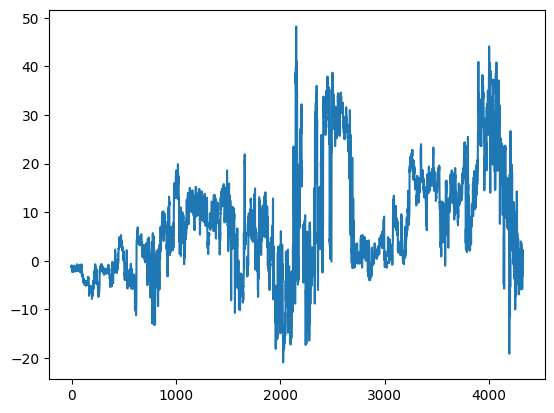

In [125]:
sw_u.V_Y_GSE.plot()

<Axes: >

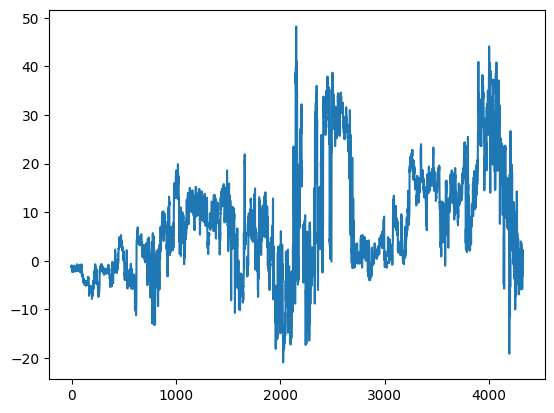

In [126]:
sw_uu.V_Y_GSE.plot()

In [127]:
coord_u

,Epoch,X_GSE,Y_GSE,Z_GSE
0,2022-11-24 13:10:12+00:00,219.074945,-10.844465,23.309501
1,2022-11-24 13:10:28+00:00,219.074945,-10.844152,23.309501
2,2022-11-24 13:10:44+00:00,219.074945,-10.843995,23.309501
3,2022-11-24 13:11:00+00:00,219.074788,-10.843681,23.309658
4,2022-11-24 13:11:16+00:00,219.074788,-10.843368,23.309658
...,...,...,...,...
2695,2022-11-25 01:08:52+00:00,218.985105,-10.058012,23.350737
2696,2022-11-25 01:09:08+00:00,218.984948,-10.057698,23.350737
2697,2022-11-25 01:09:24+00:00,218.984948,-10.057385,23.350737
2698,2022-11-25 01:09:40+00:00,218.984948,-10.057071,23.350737


In [128]:
merged = pd.merge_asof(
    mfi_u,
    sw_u,
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("2min"),
    suffixes=("_mfi", "_sw"),
)

coord_u = dscovr_coord.reset_index().sort_values("time")
coord_u.time = coord_u.time.astype('datetime64[ns, UTC]')
merged = pd.merge_asof(
    merged,
    coord_u,
    on="time",
    direction="nearest",
    tolerance=pd.Timedelta("2min"),
)

merged = merged.set_index("time").sort_index()
merged = merged.dropna(subset=list(mag.columns) + list(sw.columns), how="all")

In [129]:
parquet_path = save_parquet(merged, "DSCOVR", tShock)
parquet_path

WindowsPath('Data/2022-11-24 19-10-00/DSCOVR.parquet')

In [130]:
merged

,B_X_GSE,B_Y_GSE,B_Z_GSE,B,V_X_GSE,V_Y_GSE,V_Z_GSE,V,N_p,T,X_GSE,Y_GSE,Z_GSE
time,,,,,,,,,,,,,
2022-11-24 00:00:00+00:00,-0.87,-0.47,-0.08,0.99,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
2022-11-24 00:00:01+00:00,-0.79,-0.38,0.10,0.89,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
2022-11-24 00:00:02+00:00,-0.76,-0.30,0.22,0.85,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
2022-11-24 00:00:03+00:00,-0.78,-0.34,0.26,0.89,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
2022-11-24 00:00:04+00:00,-0.82,-0.34,0.21,0.91,-290.000000,-1.0,-15.800000,290.399994,29.90,18348.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-24 23:59:55+00:00,-4.87,9.40,10.14,14.66,-395.399994,-3.1,20.700001,395.899994,9.33,145999.0,242.61331,-17.898341,12.385178
2022-11-24 23:59:56+00:00,-4.93,9.40,10.17,14.69,-395.399994,-3.1,20.700001,395.899994,9.33,145999.0,242.61331,-17.898341,12.385178
2022-11-24 23:59:57+00:00,-4.86,9.35,10.18,14.65,-395.399994,-3.1,20.700001,395.899994,9.33,145999.0,242.61331,-17.898341,12.385178


# THEMIS-B

## Magnetic Field

In [131]:
# List available datasets for THEMIS magnetic field
datasets = list_datasets("THEMIS", "Magnetic Fields (space)")


=== THEMIS - Magnetic Fields (space) ===
0. THA_L2_FBK, Probe Electric Field Instrument and Search Coil Magnetometer Instrument, Digital Fields Board- digitally computed Filter Bank spectra and E12 peak and average in HF band. - V. Angelopoulos, J. W. Bonnell & F. S. Mozer; A. Roux and R. E. Ergun (UCB; CETP and LASP respectively, NASA NAS5-02099)
1. THA_L2_FFT, THEMIS-A:  On Board Fast Fourier Transform (FFT) power spectra of Electric (EFI) and Magnetic (SCM) field, for particle and wave burst survey modes. - V. Angelopoulos  (UCB, NASA NAS5-02099)
2. THA_L2_FGM, Spacecraft-collected fluxgate magnetometer, Decimated TeleMetry High, DSL, GSE and GSM coordinates - V. Angelopoulos, U. Auster & K.H. Glassmeier and W. Baumjohann (UCB, TUBS and IWF respectively, NASA NAS5-02099)
3. THA_L2_FIT, THEMIS-A:  On Board spin fits of Electric (EFI) and Magnetic (FGM) field.  - V. Angelopoulos  (UCB, NASA NAS5-02099)
4. THA_L2_SCM, Spacecraft-collected search-coil magnetometer (SCM) Magnetic field 

In [132]:
# Download THEMIS-B magnetic field data
N = 7
df = download_and_unpack(datasets, N, time_interval)


=== Variables for THB_L2_FGM ===
Time Interval: {'Start': '2007-02-24T00:00:00.000Z', 'End': '2026-03-31T00:00:00.000Z'}
0. thb_fgm_fgs_quality, FGM-FGS Data Quality (0: Good data, 1:boom not deployed, 2:in shadow, 3:uncorrected shadow, 4:noisy waveforms) [units: None]
1. thb_fgs_btotalQ, (Good data only) FGS magnetic field B magnitude  [units: None]
2. thb_fgs_gseQ, ---- FGS (spin-resolution/~3 sec) magnetic  field B in XYZ GSE Coordinates [units: None]
3. thb_fgs_gsmQ, ---- FGS (spin-resolution/~3 sec) magnetic  field B in XYZ GSM Coordinates [units: None]
4. thb_fgs_dslQ, ---- FGS magnetic field B in DSL (Despun Spacecraft) Coordinates  [units: None]
5. thb_fgs_btotal, (All Qualities data) FGS magnetic field B magnitude  [units: None]
6. thb_fgs_gse, ---- FGS (spin-resolution/~3 sec) magnetic  field B in XYZ GSE Coordinates [units: None]
7. thb_fgs_gsm, ---- FGS magnetic field B in XYZ GSM Coordinates [units: None]
8. thb_fgs_dsl, ---- FGS magnetic field B in XYZ DSL (Despun Spacec

<class 'pandas.DataFrame'>
DatetimeIndex: 10053 entries, 2022-11-24 13:10:01.745000 to 2022-11-25 01:09:58.411000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   B_X_GSE  10053 non-null  float64
 1   B_Y_GSE  10053 non-null  float64
 2   B_Z_GSE  10053 non-null  float64
 3   B        10053 non-null  float64
dtypes: float64(4)
memory usage: 392.7 KB


<Axes: xlabel='thb_fgs_epoch'>

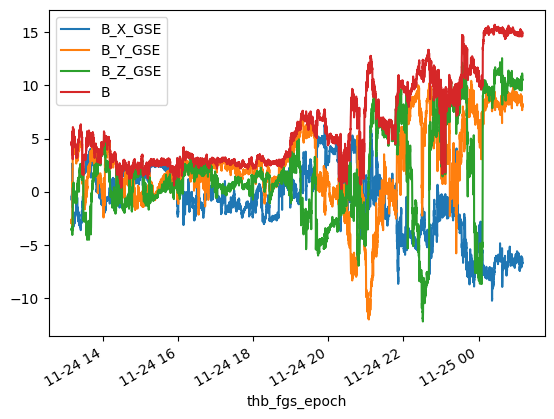

In [133]:
# магнитное поле 1 min
THEMIS_MFI = df.filter(["thb_fgs_epoch", "thb_fgs_btotal", "thb_fgs_gse"], axis=1)
THEMIS_MFI = THEMIS_MFI.set_index("thb_fgs_epoch")
THEMIS_MFI.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
THEMIS_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE"]] = pd.DataFrame(
    THEMIS_MFI["thb_fgs_gse"].tolist(), index=THEMIS_MFI.index
)
THEMIS_MFI = THEMIS_MFI.drop(["thb_fgs_gse"], axis=1)
THEMIS_MFI["B"] = THEMIS_MFI.thb_fgs_btotal
THEMIS_MFI = THEMIS_MFI.drop(["thb_fgs_btotal"], axis=1)
# фильтр плохих данных
# THEMIS_MFI = THEMIS_MFI.mask((THEMIS_MFI["B"] > 1e5) | (THEMIS_MFI["B"] < 1e-4))
# THEMIS_MFI = THEMIS_MFI.mask((THEMIS_MFI["B_X_GSE"] > 1e5) | (THEMIS_MFI["B_X_GSE"] < 1e-4))
# THEMIS_MFI = THEMIS_MFI.mask((THEMIS_MFI["B_Y_GSE"] > 1e5) | (THEMIS_MFI["B_Y_GSE"] < 1e-4))
# THEMIS_MFI = THEMIS_MFI.mask((THEMIS_MFI["B_Z_GSE"] > 1e5) | (THEMIS_MFI["B_Z_GSE"] < 1e-4))
THEMIS_MFI = clamp_bad_values(THEMIS_MFI)
THEMIS_MFI.info()
# усреднение 1 час начиная с 00
# df_MFI_1h_edit=df_MFI_1h.resample('1h').mean()

THEMIS_MFI.plot()

## Coords

In [134]:
# List available datasets for THEMIS magnetic field
datasets = list_datasets("THEMIS", "Ephemeris/Attitude/Ancillary")


=== THEMIS - Ephemeris/Attitude/Ancillary ===
0. THAPRED_OR_SSC, THEMIS-A Predicted Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
1. THA_L1_STATE, Probe state file, contains position, attitude, sun pulse data - V. Angelopoulos (UCB, NASA NAS5-02099)
2. THA_OR_SSC, Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
3. THBPRED_OR_SSC, THEMIS-B Predicted Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
4. THB_HELIO1HR_POSITION, Position in heliocentric coordinates from SPDF Helioweb - Natalia Papitashvili (NASA/GSFC/SPDF)
5. THB_L1_STATE, Probe state file, contains position, attitude, sun pulse data - V. Angelopoulos (UCB, NASA NAS5-02099)
6. THB_OR_SSC, Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
7. THCPRED_OR_SSC, THEMIS-C Predicted Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
8. THC_HELIO1HR_POSITION, Position in heliocentric coordinates from SPDF Helioweb - Natalia Papitashvili (NASA/GSFC/SPDF)
9. THC_L1_STATE, Probe state file, contains position, attitu

In [135]:
# Download THEMIS-B magnetic field data
N = 7
df = download_and_unpack(datasets, N, time_interval)


=== Variables for THCPRED_OR_SSC ===
Time Interval: {'Start': '2008-07-18T00:30:00.000Z', 'End': '2029-10-01T23:59:00.000Z'}
0. RADIUS, Radial distance from the spacecraft to Earth. [units: None]
1. XYZ_GSE, XYZ in GSE coordinates (time-series) [units: None]
2. XYZ_GSEO, XYZ in GSE coordinates (orbit) [units: None]
3. GSE_LAT, Latitude in GSE Coordinate System  [units: None]
4. GSE_LON, Longitude in GSE coordinate system [units: None]
5. GSE_LCT_T, Spacecraft Local Time in GSE coordinates [units: None]
6. XYZ_GSM, XYZ in GSM coordinates (time-series) [units: None]
7. XYZ_GSMO, XYZ in GSM coordinates (orbit) [units: None]
8. GSM_LAT, Latitude in GSM coordinate system  [units: None]
9. GSM_LON, Longitude in GSM coordinate system [units: None]
10. XYZ_SM, XYZ in SM coordinates (time-series) [units: None]
11. XYZ_SMO, XYZ in SM coordinates (orbit) [units: None]
12. SM_LAT, Latitude in SM coordinate system  [units: None]
13. SM_LON, Longitude in SM coordinate system  [units: None]
14. SM_L

In [136]:
# магнитное поле 1 min
Themis_B = df.filter(["Epoch", "XYZ_GSE"], axis=1)
Themis_B = Themis_B.set_index("Epoch")
Themis_B.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Themis_B[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    Themis_B["XYZ_GSE"].tolist(), index=Themis_B.index
)
Themis_B = Themis_B.drop(["XYZ_GSE"], axis=1)
Themis_B = coerce_distance_cols_to_re(
    Themis_B,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="THEMIS_B",
    unit_hint=LAST_VAR_UNITS.get("XYZ_GSE"),
)
Themis_B.info()
# усреднение 1 час начиная с 00
# df_GSE_1h_edit=df_GSE_1h.resample('1h').mean()

[THEMIS_B] X_GSE: unit=re -> R_e (x1); |median| 52.9772 -> 52.9772
[THEMIS_B] Y_GSE: unit=re -> R_e (x1); |median| 10.7646 -> 10.7646
[THEMIS_B] Z_GSE: unit=re -> R_e (x1); |median| 3.05078 -> 3.05078
<class 'pandas.DataFrame'>
DatetimeIndex: 721 entries, 2022-11-24 13:10:00 to 2022-11-25 01:10:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X_GSE   721 non-null    float64
 1   Y_GSE   721 non-null    float64
 2   Z_GSE   721 non-null    float64
dtypes: float64(3)
memory usage: 22.5 KB


## Plot and Export

In [137]:
mfi = THEMIS_MFI.copy()
# sw = Ace_SW.copy()
coord = Themis_B.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
# sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

# merged = pd.merge_asof(
#     mfi_u,
#     sw_u,
#     on="Epoch",
#     direction="nearest",
#     tolerance=tol,
#     suffixes=("_mfi", "_sw"),
# )
merged = pd.merge_asof(mfi_u, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols, how="all")

In [138]:
save_parquet(merged, "THEMIS_B", tShock)

WindowsPath('Data/2022-11-24 19-10-00/THEMIS_B.parquet')

# THEMIS-C

## Magnetic Field

In [139]:
# List available datasets for THEMIS magnetic field
datasets = list_datasets("THEMIS", "Magnetic Fields (space)")


=== THEMIS - Magnetic Fields (space) ===
0. THA_L2_FBK, Probe Electric Field Instrument and Search Coil Magnetometer Instrument, Digital Fields Board- digitally computed Filter Bank spectra and E12 peak and average in HF band. - V. Angelopoulos, J. W. Bonnell & F. S. Mozer; A. Roux and R. E. Ergun (UCB; CETP and LASP respectively, NASA NAS5-02099)
1. THA_L2_FFT, THEMIS-A:  On Board Fast Fourier Transform (FFT) power spectra of Electric (EFI) and Magnetic (SCM) field, for particle and wave burst survey modes. - V. Angelopoulos  (UCB, NASA NAS5-02099)
2. THA_L2_FGM, Spacecraft-collected fluxgate magnetometer, Decimated TeleMetry High, DSL, GSE and GSM coordinates - V. Angelopoulos, U. Auster & K.H. Glassmeier and W. Baumjohann (UCB, TUBS and IWF respectively, NASA NAS5-02099)
3. THA_L2_FIT, THEMIS-A:  On Board spin fits of Electric (EFI) and Magnetic (FGM) field.  - V. Angelopoulos  (UCB, NASA NAS5-02099)
4. THA_L2_SCM, Spacecraft-collected search-coil magnetometer (SCM) Magnetic field 

In [140]:
# Download THEMIS-C magnetic field data
N = 12
df = download_and_unpack(datasets, N, time_interval)


=== Variables for THC_L2_FGM ===
Time Interval: {'Start': '2007-02-22T00:00:00.000Z', 'End': '2026-03-31T00:00:00.000Z'}
0. thc_fgm_fgs_quality, FGM-FGS Data Quality (0: Good data, 1:boom not deployed, 2:in shadow, 3:uncorrected shadow, 4:noisy waveforms) [units: None]
1. thc_fgs_btotalQ, (Good data only) FGS magnetic field B magnitude  [units: None]
2. thc_fgs_gseQ, ---- FGS (spin-resolution/~3 sec) magnetic  field B in XYZ GSE Coordinates [units: None]
3. thc_fgs_gsmQ, ---- FGS (spin-resolution/~3 sec) magnetic  field B in XYZ GSM Coordinates [units: None]
4. thc_fgs_dslQ, ---- FGS magnetic field B in DSL (Despun Spacecraft) Coordinates  [units: None]
5. thc_fgs_btotal, (All Qualities data) FGS magnetic field B magnitude  [units: None]
6. thc_fgs_gse, ---- FGS (spin-resolution/~3 sec) magnetic  field B in XYZ GSE Coordinates [units: None]
7. thc_fgs_gsm, ---- FGS magnetic field B in XYZ GSM Coordinates [units: None]
8. thc_fgs_dsl, ---- FGS magnetic field B in XYZ DSL (Despun Spacec

<class 'pandas.DataFrame'>
DatetimeIndex: 10514 entries, 2022-11-24 13:10:03.574000 to 2022-11-25 01:09:59.028000
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   B_X_GSE  10514 non-null  float64
 1   B_Y_GSE  10514 non-null  float64
 2   B_Z_GSE  10514 non-null  float64
 3   B        10514 non-null  float64
dtypes: float64(4)
memory usage: 410.7 KB


<Axes: xlabel='thc_fgs_epoch'>

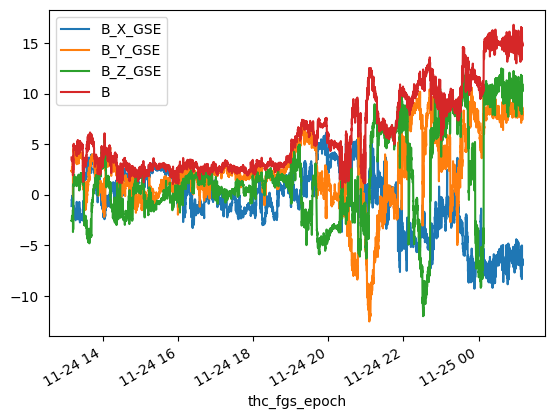

In [141]:
# магнитное поле 1 min
THEMIS_C_MFI = df.filter(["thc_fgs_epoch", "thc_fgs_btotal", "thc_fgs_gse"], axis=1)
THEMIS_C_MFI = THEMIS_C_MFI.set_index("thc_fgs_epoch")
THEMIS_C_MFI.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
THEMIS_C_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE"]] = pd.DataFrame(
    THEMIS_C_MFI["thc_fgs_gse"].tolist(), index=THEMIS_C_MFI.index
)
THEMIS_C_MFI = THEMIS_C_MFI.drop(["thc_fgs_gse"], axis=1)
THEMIS_C_MFI["B"] = THEMIS_C_MFI.thc_fgs_btotal
THEMIS_C_MFI = THEMIS_C_MFI.drop(["thc_fgs_btotal"], axis=1)
# фильтр плохих данных
# THEMIS_C_MFI = THEMIS_C_MFI.mask((THEMIS_C_MFI["B"] > 1e5) | (THEMIS_C_MFI["B"] < 1e-4))
# THEMIS_C_MFI = THEMIS_C_MFI.mask((THEMIS_C_MFI["B_X_GSE"] > 1e5) | (THEMIS_C_MFI["B_X_GSE"] < 1e-4))
# THEMIS_C_MFI = THEMIS_C_MFI.mask((THEMIS_C_MFI["B_Y_GSE"] > 1e5) | (THEMIS_C_MFI["B_Y_GSE"] < 1e-4))
# THEMIS_C_MFI = THEMIS_C_MFI.mask((THEMIS_C_MFI["B_Z_GSE"] > 1e5) | (THEMIS_C_MFI["B_Z_GSE"] < 1e-4))
THEMIS_C_MFI = clamp_bad_values(THEMIS_C_MFI)
THEMIS_C_MFI.info()

THEMIS_C_MFI.plot()

## Coords

In [142]:
# List available datasets for THEMIS ephemeris
datasets = list_datasets("THEMIS", "Ephemeris/Attitude/Ancillary")


=== THEMIS - Ephemeris/Attitude/Ancillary ===
0. THAPRED_OR_SSC, THEMIS-A Predicted Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
1. THA_L1_STATE, Probe state file, contains position, attitude, sun pulse data - V. Angelopoulos (UCB, NASA NAS5-02099)
2. THA_OR_SSC, Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
3. THBPRED_OR_SSC, THEMIS-B Predicted Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
4. THB_HELIO1HR_POSITION, Position in heliocentric coordinates from SPDF Helioweb - Natalia Papitashvili (NASA/GSFC/SPDF)
5. THB_L1_STATE, Probe state file, contains position, attitude, sun pulse data - V. Angelopoulos (UCB, NASA NAS5-02099)
6. THB_OR_SSC, Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
7. THCPRED_OR_SSC, THEMIS-C Predicted Orbit parameters from SSCWeb - SSCWeb (SPDF/Goddard)
8. THC_HELIO1HR_POSITION, Position in heliocentric coordinates from SPDF Helioweb - Natalia Papitashvili (NASA/GSFC/SPDF)
9. THC_L1_STATE, Probe state file, contains position, attitu

In [143]:
# Download THEMIS-C ephemeris data
N = 9
df = download_and_unpack(datasets, N, time_interval)


=== Variables for THC_L1_STATE ===
Time Interval: {'Start': '2007-02-17T23:36:00.000Z', 'End': '2026-03-31T23:59:00.000Z'}
0. thc_pos, thc_position XYZ in GEI (timeseries plot) [units: None]
1. thc_posV, thc_position XYZ in GEI (orbit plot) [units: None]
2. thc_vel, thc_velocity [units: None]
3. thc_spin_initial_delta_phi, [Not populated yet] Initial angle offset between IDPU model and eclipse model in this segment. [units: None]
4. thc_spin_idpu_spinper, [Not populated yet] IDPU spin period [units: None]
5. thc_spin_segflags, [Not populated yet] Marker for eclipse segments. [units: None]
6. thc_spin_ecl_initial_delta_phi, Initial angle offset between IDPU model and eclipse model in this segment (eclipse spin model). [units: None]
7. thc_spin_ecl_idpu_spinper, IDPU spin period (eclipse spin model) [units: None]
8. thc_spin_ecl_segflags, Marker for eclipse segments (eclipse spin model). [units: None]
9. thc_pos_gse, thc_position XYZ in GSE (timeseries plot) [units: None]
10. thc_pos_gs

In [144]:
df

,thc_state_epoch,thc_spin_epoch,thc_spin_ecl_epoch,thc_state_epoch0,thc_spin_epoch0,thc_pos,thc_posV,thc_vel,thc_spin_initial_delta_phi,thc_spin_idpu_spinper,...,thc_pos_sse_compno,thc_vel_sel_compno,thc_vel_sse_compno,metavar0,metavar1,metavar2,metavar3,metavar4,metavar5,metavar6
0,2022-11-24 13:10:00,2022-11-24 13:28:16.926,2022-11-24 13:28:16.926,1970-01-01,1970-01-01,"[-116654.953125, -291060.09375, -145382.21875]","[-116654.953125, -291060.09375, -145382.21875]","[0.8111141920089722, -0.2377050518989563, -0.2...",0.0,0.0,...,1,1,1,"X, GEI",km,km/s,"X, GSE","X, GSM","X, SEL","X, SSE"
1,2022-11-24 13:11:00,2022-11-24 13:28:21.035,2022-11-24 13:28:21.035,1970-01-01,1970-01-01,"[-116606.296875, -291074.34375, -145394.546875]","[-116606.296875, -291074.34375, -145394.546875]","[0.8109177947044373, -0.23826012015342712, -0....",0.0,0.0,...,2,2,2,"Y, GEI",km,km/s,"Y, GSE","Y, GSM","Y, SEL","Y, SSE"
2,2022-11-24 13:12:00,2022-11-24 13:48:24.901,2022-11-24 13:48:24.901,1970-01-01,1970-01-01,"[-116557.6484375, -291088.65625, -145406.890625]","[-116557.6484375, -291088.65625, -145406.890625]","[0.8107218146324158, -0.2388155311346054, -0.2...",0.0,0.0,...,3,3,3,"Z, GEI",km,km/s,"Z, GSE","Z, GSM","Z, SEL","Z, SSE"
3,2022-11-24 13:13:00,2022-11-24 13:48:29.010,2022-11-24 13:48:29.010,1970-01-01,1970-01-01,"[-116509.0078125, -291103.03125, -145419.234375]","[-116509.0078125, -291103.03125, -145419.234375]","[0.8105262517929077, -0.23937126994132996, -0....",0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2022-11-24 13:14:00,2022-11-24 14:08:32.876,2022-11-24 14:08:32.876,1970-01-01,1970-01-01,"[-116460.3828125, -291117.40625, -145431.578125]","[-116460.3828125, -291117.40625, -145431.578125]","[0.8103311061859131, -0.23992733657360077, -0....",0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
716,2022-11-25 01:06:00,NaT,NaT,1970-01-01,1970-01-01,"[-81630.3671875, -315670.84375, -157622.78125]","[-81630.3671875, -315670.84375, -157622.78125]","[1.3192592859268188, -1.4676477909088135, -0.5...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
717,2022-11-25 01:07:00,NaT,NaT,1970-01-01,1970-01-01,"[-81550.7734375, -315759.15625, -157654.09375]","[-81550.7734375, -315759.15625, -157654.09375]","[1.3339062929153442, -1.4767560958862305, -0.5...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
718,2022-11-25 01:08:00,NaT,NaT,1970-01-01,1970-01-01,"[-81470.28125, -315848.03125, -157685.5625]","[-81470.28125, -315848.03125, -157685.5625]","[1.3491219282150269, -1.4859203100204468, -0.5...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
719,2022-11-25 01:09:00,NaT,NaT,1970-01-01,1970-01-01,"[-81388.8671875, -315937.46875, -157717.171875]","[-81388.8671875, -315937.46875, -157717.171875]","[1.3649356365203857, -1.4951319694519043, -0.5...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [145]:
# магнитное поле 1 min
Themis_C = df.filter(["thc_state_epoch", "thc_pos_gse"], axis=1)
Themis_C = Themis_C.set_index("thc_state_epoch")
Themis_C.rename(columns={"thc_state_epoch": "Epoch"}, inplace=True)
Themis_C.dropna(inplace=True)
# распаковка списка bx by bz в отдельные столбцы
Themis_C[["X_GSE", "Y_GSE", "Z_GSE"]] = pd.DataFrame(
    Themis_C["thc_pos_gse"].tolist(), index=Themis_C.index
)
Themis_C = Themis_C.drop(["thc_pos_gse"], axis=1)
Themis_C = clamp_bad_values(Themis_C)
Themis_C = coerce_distance_cols_to_re(
    Themis_C,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="THEMIS_C",
    unit_hint=LAST_VAR_UNITS.get("thc_pos_gse"),
)
Themis_C.info()

[THEMIS_C] X_GSE: unit=km -> R_e (x0.000156788962); |median| 342120 -> 53.6407
[THEMIS_C] Y_GSE: unit=km -> R_e (x0.000156788962); |median| 65795 -> 10.3159
[THEMIS_C] Z_GSE: unit=km -> R_e (x0.000156788962); |median| 19127.7 -> 2.99901
<class 'pandas.DataFrame'>
DatetimeIndex: 721 entries, 2022-11-24 13:10:00 to 2022-11-25 01:10:00
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X_GSE   721 non-null    float64
 1   Y_GSE   721 non-null    float64
 2   Z_GSE   721 non-null    float64
dtypes: float64(3)
memory usage: 22.5 KB


## Plot and Export

In [146]:
mfi = THEMIS_MFI.copy()
# sw = Ace_SW.copy()
coord = Themis_B.copy()

# Normalize index names and to UTC datetime index
for df in (mfi, sw, coord):
    df.index = pd.to_datetime(df.index, utc=True)
    df.index.name = "Epoch"

# Replace CDAS fill values (e.g., -1e31) with NaN
mfi = clamp_bad_values(mfi)
coord = clamp_bad_values(coord)

# Pick a "unified" epoch grid — here we use MFI timestamps
# You can swap to sw.index or coord.index if preferred.
epoch = mfi.index

# Nearest-time merge with tolerance (e.g., 2 minutes)
tol = pd.Timedelta("2min")

mfi_u = mfi.reset_index().sort_values("Epoch")
# sw_u = sw.reset_index().sort_values("Epoch")
coord_u = coord.reset_index().sort_values("Epoch")

# merged = pd.merge_asof(
#     mfi_u,
#     sw_u,
#     on="Epoch",
#     direction="nearest",
#     tolerance=tol,
#     suffixes=("_mfi", "_sw"),
# )
merged = pd.merge_asof(mfi_u, coord_u, on="Epoch", direction="nearest", tolerance=tol)

merged = merged.set_index("Epoch").sort_index()

mfi_cols = list(mfi.columns)
sw_cols = list(sw.columns)

merged = merged.dropna(subset=mfi_cols, how="all")

In [147]:
save_parquet(merged, "THEMIS_C", tShock)

WindowsPath('Data/2022-11-24 19-10-00/THEMIS_C.parquet')

# MMS

## Magnetic Field

In [148]:
datasets = list_datasets("MMS", "Magnetic Fields (space)")


=== MMS - Magnetic Fields (space) ===
0. MMS1_DSP_FAST_L2_BPSD, SCM Low frequency Magnetic spectral density from the FIELDS Digital Signal Processor - J. Burch, R. Ergun, O. Le Contel (SWRI, LASP, LPP)
1. MMS1_DSP_SLOW_L2_BPSD, search coil magnetometer spectral density - J. Burch, R. Ergun, O. Le Contel (SWRI, LASP, LPP)
2. MMS1_FGM_BRST_L2, Level2 Flux Gate Magnetometer Burst DC Magnetic Field for MMS Satellite Number 1 - J. Burch, C. Russell, W. Magnus (SWRI, UCLA, IWF)
3. MMS1_FGM_SRVY_L2, Level2 Flux Gate Magnetometer Combined Fast/Slow Survey DC Magnetic Field for MMS Satellite Number 1 - J. Burch, C. Russell, W. Magnus (SWRI, UCLA, IWF)
4. MMS1_R0_SUMMARY, Links to MMS-1 pre-generated Quicklook Summary plots - James Burch (SWRI)
5. MMS1_SCM_BRST_L2_SCB, Level 2 Search Coil Magnetometer AC Magnetic Field Burst (8192S/s) Data - J. Burch, O. Le Contel (SWRI, LPP)
6. MMS1_SCM_BRST_L2_SCHB, Level 2 Search Coil Magnetometer AC Magnetic Field High Burst (16384S/s) Data - J. Burch, O. L

In [149]:
# Download THEMIS-C ephemeris data
N = 3
df = download_and_unpack(datasets, N, time_interval)
df


=== Variables for MMS1_FGM_SRVY_L2 ===
Time Interval: {'Start': '2015-09-01T00:00:12.000Z', 'End': '2026-02-26T23:59:59.000Z'}
0. mms1_fgm_b_gse_srvy_l2_clean, Magnetic field vector in Geocentric Solar Ecliptic (GSE) cartesian coordinates plus Btotal (8 or 16 S/s) [units: None]
1. mms1_fgm_b_gse_srvy_l2, ---> Magnetic field vector in Geocentric Solar Ecliptic (GSE) cartesian coordinates plus Btotal (8 or 16 S/s), including flagged data [units: None]
2. mms1_fgm_b_gsm_srvy_l2_clean, Magnetic field vector in Geocentric Solar Magnetospheric (GSM) cartesian coordinates plus Btotal (8 or 16 S/s) [units: None]
3. mms1_fgm_b_gsm_srvy_l2, ---> Magnetic field vector in Geocentric Solar Magnetospheric (GSM) cartesian coordinates plus Btotal (8 or 16 S/s), including flagged data [units: None]
4. mms1_fgm_b_dmpa_srvy_l2_clean, Magnetic field vector in Despun MPA-aligned cartesian coordinates plus Btotal (8 or 16 S/s) [units: None]
5. mms1_fgm_b_dmpa_srvy_l2, ---> Magnetic field vector in Despun M

,mms1_fgm_b_gse_srvy_l2,mms1_fgm_b_gse_srvy_l2_clean,mms1_fgm_b_gsm_srvy_l2_clean,mms1_fgm_b_gsm_srvy_l2,mms1_fgm_b_dmpa_srvy_l2_clean,mms1_fgm_b_dmpa_srvy_l2,mms1_fgm_b_bcs_srvy_l2_clean,mms1_fgm_b_bcs_srvy_l2,mms1_fgm_flag_srvy_l2,mms1_fgm_r_gse_srvy_l2,...,Epoch,Epoch_state,mms1_fgm_bdeltahalf_srvy_l2,mms1_fgm_rdeltahalf_srvy_l2,metavar0,metavar1,metavar2,metavar3,metavar4,metavar5
0,"[1.2369532585144043, 1.2237735986709595, 0.384...","[1.2369532585144043, 1.2237735986709595, 0.384...","[1.2369532585144043, 1.2823460102081299, -0.03...","[1.2369532585144043, 1.2823460102081299, -0.03...","[1.2135776281356812, 1.223609209060669, 0.4535...","[1.2135776281356812, 1.223609209060669, 0.4535...","[0.21316376328468323, 1.7106167078018188, 0.45...","[0.21316376328468323, 1.7106167078018188, 0.45...",0,"[-26242.41015625, 115180.25, -57704.18359375, ...",...,2022-11-24 13:10:00.055199,2022-11-24 13:10:23.586,0.03125,15.000001,Bx GSE,Bx GSM,Bx DMPA,Bx BCS,X GSE,X GSM
1,"[1.6042612791061401, 1.5260740518569946, 0.479...","[1.6042612791061401, 1.5260740518569946, 0.479...","[1.6042612791061401, 1.5990688800811768, -0.04...","[1.6042612791061401, 1.5990688800811768, -0.04...","[1.5750312805175781, 1.5259171724319458, 0.568...","[1.5750312805175781, 1.5259171724319458, 0.568...","[0.3578658998012543, 2.164165496826172, 0.5665...","[0.3578658998012543, 2.164165496826172, 0.5665...",0,"[-26251.91796875, 115140.1328125, -57697.16406...",...,2022-11-24 13:10:00.117700,2022-11-24 13:10:53.586,0.03125,15.000001,By GSE,By GSM,By DMPA,By BCS,Y GSE,Y GSM
2,"[1.6946790218353271, 1.5887986421585083, 0.543...","[1.6946790218353271, 1.5887986421585083, 0.543...","[1.6946790218353271, 1.6790682077407837, -0.00...","[1.6946790218353271, 1.6790682077407837, -0.00...","[1.6618802547454834, 1.5885275602340698, 0.637...","[1.6618802547454834, 1.5885275602340698, 0.637...","[0.4355015158653259, 2.257983446121216, 0.6348...","[0.4355015158653259, 2.257983446121216, 0.6348...",0,"[-26261.4140625, 115099.9921875, -57690.136718...",...,2022-11-24 13:10:00.180201,2022-11-24 13:11:23.586,0.03125,15.000001,Bz GSE,Bz GSM,Bz DMPA,Bz BCS,Z GSE,Z GSM
3,"[1.7582217454910278, 1.6020227670669556, 0.627...","[1.7582217454910278, 1.6020227670669556, 0.627...","[1.7582217454910278, 1.7189531326293945, 0.070...","[1.7582217454910278, 1.7189531326293945, 0.070...","[1.720846176147461, 1.6015576124191284, 0.7244...","[1.720846176147461, 1.6015576124191284, 0.7244...","[0.5218092203140259, 2.292865753173828, 0.7222...","[0.5218092203140259, 2.292865753173828, 0.7222...",0,"[-26270.953125, 115059.828125, -57683.1015625,...",...,2022-11-24 13:10:00.242701,2022-11-24 13:11:53.586,0.03125,15.000001,Bt,Bt,Bt,Bt,R,R
4,"[1.8298726081848145, 1.576512098312378, 0.7416...","[1.8298726081848145, 1.576512098312378, 0.7416...","[1.8298726081848145, 1.732145071029663, 0.1873...","[1.8298726081848145, 1.732145071029663, 0.1873...","[1.7863223552703857, 1.5757712125778198, 0.842...","[1.7863223552703857, 1.5757712125778198, 0.842...","[0.6362690329551697, 2.2962424755096436, 0.840...","[0.6362690329551697, 2.2962424755096436, 0.840...",0,"[-26280.44921875, 115019.640625, -57676.054687...",...,2022-11-24 13:10:00.305202,2022-11-24 13:12:23.586,0.03125,15.000001,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691696,"[-79.56798553466797, 41.119205474853516, -1.96...","[-79.56798553466797, 41.119205474853516, -1.96...","[-79.56798553466797, 40.9569206237793, -4.1471...","[-79.56798553466797, 40.9569206237793, -4.1471...","[-79.36383819580078, 41.10739517211914, -6.107...","[-79.36383819580078, 41.10739517211914, -6.107...","[30.661418914794922, 83.9490966796875, -6.1773...","[30.661418914794922, 83.9490966796875, -6.1773...",0,None,...,2022-11-25 01:09:59.689732,NaT,0.03125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
691697,"[-79.56475830078125, 41.11832046508789, -1.957...","[-79.56475830078125, 41.11832046508789, -1.957...","[-79.56475830078125, 40

In [150]:
df["mms1_fgm_r_gse_srvy_l2"]

0         [-26242.41015625, 115180.25, -57704.18359375, ...
1         [-26251.91796875, 115140.1328125, -57697.16406...
2         [-26261.4140625, 115099.9921875, -57690.136718...
3         [-26270.953125, 115059.828125, -57683.1015625,...
4         [-26280.44921875, 115019.640625, -57676.054687...
                                ...                        
691696                                                 None
691697                                                 None
691698                                                 None
691699                                                 None
691700                                                 None
Name: mms1_fgm_r_gse_srvy_l2, Length: 691701, dtype: object

[MMS1] X_GSE: unit=km -> R_e (x0.000156788962); |median| 31328.4 -> 4.91194
[MMS1] Y_GSE: unit=km -> R_e (x0.000156788962); |median| 80823.2 -> 12.6722
[MMS1] Z_GSE: unit=km -> R_e (x0.000156788962); |median| 49732.5 -> 7.7975


<Axes: xlabel='Epoch'>

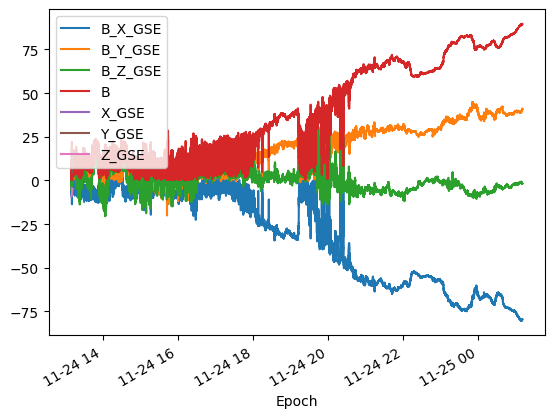

In [151]:
# магнитное поле 1 min
MMS_MFI = df.filter(
    ["Epoch", "mms1_fgm_b_gse_srvy_l2_clean", "mms1_fgm_r_gse_srvy_l2"], axis=1
)
MMS_MFI = MMS_MFI.set_index("Epoch")

# start by dropping rows with missing magnetic vector
MMS_MFI.dropna(subset="mms1_fgm_b_gse_srvy_l2_clean", inplace=True)

# распаковка списка bx by bz в отдельные столбцы
MMS_MFI[["B_X_GSE", "B_Y_GSE", "B_Z_GSE", "B"]] = pd.DataFrame(
    MMS_MFI["mms1_fgm_b_gse_srvy_l2_clean"].tolist(), index=MMS_MFI.index
)
MMS_MFI = MMS_MFI.drop(["mms1_fgm_b_gse_srvy_l2_clean"], axis=1)

# faster safe-unpack for position vectors:
# prefill NaNs and only assign rows that are valid vec4 values.
import numpy as np

_pos_raw = MMS_MFI["mms1_fgm_r_gse_srvy_l2"].to_numpy(dtype=object)
_coords_np = np.full((len(_pos_raw), 4), np.nan, dtype=float)
_valid_idx = []
_valid_rows = []

for i, v in enumerate(_pos_raw):
    if isinstance(v, (list, tuple, np.ndarray)) and len(v) == 4:
        try:
            _valid_rows.append([float(v[0]), float(v[1]), float(v[2]), float(v[3])])
            _valid_idx.append(i)
        except (TypeError, ValueError):
            pass

if _valid_idx:
    _coords_np[np.array(_valid_idx, dtype=int)] = np.asarray(_valid_rows, dtype=float)

coords = pd.DataFrame(
    _coords_np,
    index=MMS_MFI.index,
    columns=["X_GSE", "Y_GSE", "Z_GSE", "R"],
)

MMS_MFI = MMS_MFI.join(coords)
MMS_MFI = MMS_MFI.drop(["mms1_fgm_r_gse_srvy_l2"], axis=1)
MMS_MFI = coerce_distance_cols_to_re(
    MMS_MFI,
    ["X_GSE", "Y_GSE", "Z_GSE"],
    sat_name="MMS1",
    unit_hint=LAST_VAR_UNITS.get("mms1_fgm_r_gse_srvy_l2"),
    default_unit="km",
)
MMS_MFI = MMS_MFI.drop(["R"], axis=1)
MMS_MFI = clamp_bad_values(MMS_MFI)
MMS_MFI.plot()
## Magnetic Field

## Solar wind

In [152]:
datasets = list_datasets("MMS", "Plasma and Solar Wind")


=== MMS - Plasma and Solar Wind ===
0. MMS1_FPI_BRST_L2_DES-DIST, MMS Satellite Number 1 Dual Electron Spectrometer Burst-resolution instrument distributions - J. Burch, C. Pollock (SwRI, NASA/GSFC)
1. MMS1_FPI_BRST_L2_DES-MOMS, MMS Satellite Number 1 Dual Electron Spectrometer Burst-resolution distribution moments - J.Burch; C.Pollock, B.Giles (SwRI, NASA/GSFC)
2. MMS1_FPI_BRST_L2_DES-PARTMOMS, MMS Satellite Number 1 Dual Electron Spectrometer Burst-resolution partial moments - J. Burch, B. Giles (SwRI, GSFC)
3. MMS1_FPI_BRST_L2_DIS-DIST, MMS Satellite Number 1 Dual Ion Spectrometer Burst-resolution instrument distributions - J. Burch, C. Pollock (SwRI, NASA/GSFC)
4. MMS1_FPI_BRST_L2_DIS-MOMS, MMS Satellite Number 1 Dual Ion Spectrometer Burst-resolution distribution moments - J.Burch; C.Pollock, B.Giles (SwRI, NASA/GSFC)
5. MMS1_FPI_BRST_L2_DIS-PARTMOMS, MMS Satellite Number 1 Dual Ion Spectrometer Burst-resolution partial moments - J. Burch, B. Giles (SwRI, GSFC)
6. MMS1_FPI_FAST_L

## Plot and Export

In [153]:
save_parquet(MMS_MFI, "MMS1", tShock)

WindowsPath('Data/2022-11-24 19-10-00/MMS1.parquet')